In [ ]:
%pip install 'qiskit[visualization]'
%pip install qiskit-ibm-runtime
%pip install qiskit-aer
%pip install qiskit-addon-opt-mapper
%pip install git+https://github.com/qiskit-community/qopt-best-practices
%pip install git+https://github.com/qiskit-community/qaoa_training_pipeline
%pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 47.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9edd56a76d10ee2b65dcfa6adf1c8ce4b7f8efbe54fabf22fb15b20eaab33896
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
pip install pylatexenc

 壊れコンボ QAOA — カオスアトラクター統合版
  EXECUTION_MODE  = aer
  QAOA_DEPTH (p)  = 1
  MIXER_TYPE      = xy
  CHAOS_MODE      = both
  CHAOS_TYPE      = logistic
  CHAOS_R         = 3.99
  CHAOS_SCALE     = 0.4
  CHAOS_RESTARTS  = 3
  SHOTS (final)   = 3000
  CVAR_ALPHA      = 0.25

[graph] nodes=25, edges=140

[QAOA] qubits=25, depth=1, mixer=xy, chaos=both
[chaos mixing] β スケジュール (p×T = 1×6):
  layer 0: [0.666, 0.424, 0.641, 0.499, 0.699, 0.304]
[circuit] logical depth=94, 2q gates=164, n_params=2
[params]  構造: {'mixer': 'xy', 'n_bias': 1, 'n_gammas': 1, 'chaos_mixing': True, 'chaos_scale': 0.4}
論理量子ビット数: 25
[backend] AerSimulator (noiseless)
[swap] 選択的 SWAP 戦略 (シナジー辺のみ) を適用
  [selective SWAP] シナジー辺: 10 本
    chain  T0_弱 → T1_強 → T2_ｷｬﾝｾﾙ
    chain  T1_ｷｬﾝｾﾙ → T0_強
    chain  T3_ｷｬﾝｾﾙ → T2_強 → T1_弱
    chain  T2_弱 → T3_強 → T4_ｷｬﾝｾﾙ
    chain  T5_ｷｬﾝｾﾙ → T4_強 → T3_弱
    chain  T4_弱 → T5_強
  [selective SWAP] depth=98, 2q=188
[optimize] cobyla, max_iter=15, total_restarts=5
  [Normal Restart 1/2] カ

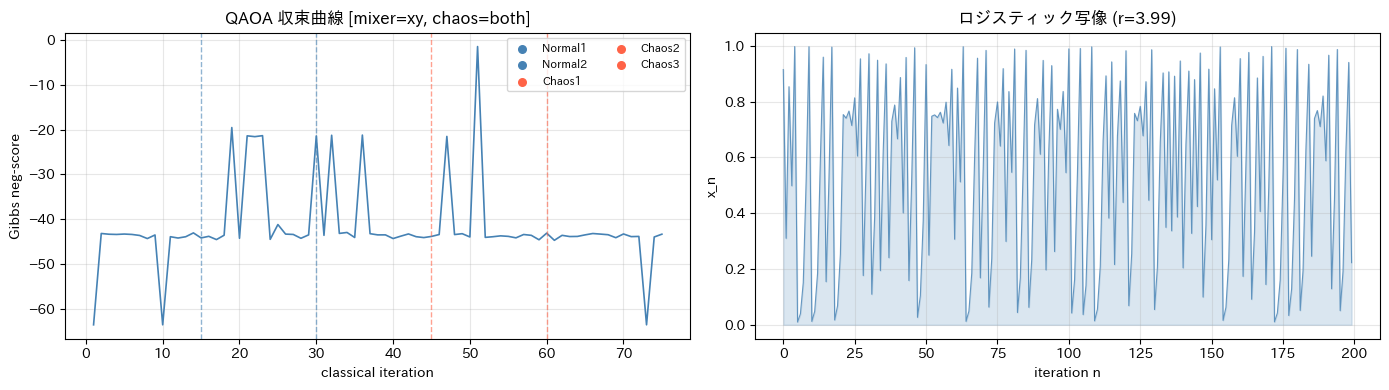

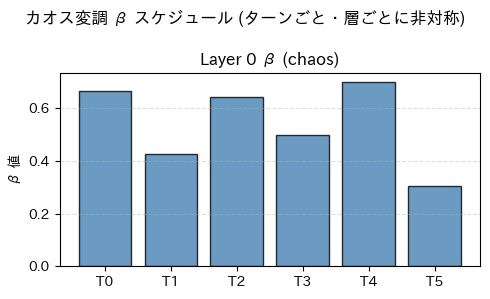

/tmp/ipykernel_4414/1270344621.py:1134: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) IPAexGothic.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


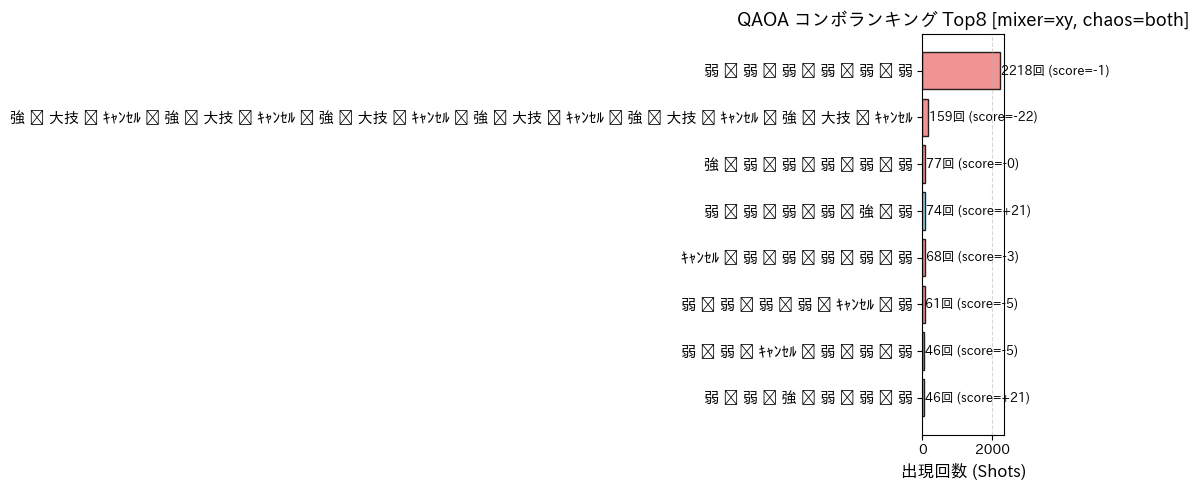


--- 論理回路 ---

--- ISA 回路 ---

=== DONE ===


In [ ]:
"""
壊れコンボ探索 QAOA — カオスアトラクター統合版
================================================

■ カオスアトラクターの統合設計
---------------------------------------------------------------------------
元コードの「XY ミキサー統合版」に、2 種類のカオス機構を追加する。

【アプローチ 1: カオス注入 (Chaotic Parameter Initialization & Perturbation)】
  ロジスティック写像 / Lorenz アトラクターのカオス時系列を
  QAOA パラメータ (β, γ) の初期値生成・再スタート時の摂動に使用する。

  従来のマルチスタート: rng.uniform で i.i.d. ランダム初期値
  → 各スタートが「独立したランダムな場所」から出発
  → 探索空間のカバレッジは確率的 (偏りが生じやすい)

  カオス注入後: ロジスティック写像 x_{n+1} = r*x_n*(1-x_n) [r=3.99]
  → 決定論的だが非周期・エルゴード的な軌道
  → 同じシード再現可能 + 空間を均等かつ密に被覆
  → 「引力盆地 (局所解) の近傍を通り過ぎても止まらず次の谷へ」

  実装: ChaosInitializer クラス
    - logistic_sequence(n): ロジスティック写像で n 個の [0,1] 値列
    - lorenz_sequence(n):   Lorenz 系の x 軸投影を [0,1] に正規化した n 個列
    - perturb(theta):       収束済みパラメータにカオス摂動を加えて局所解から脱出

【アプローチ 2: カオス・ミキシング (Chaotic Mixing Hamiltonian)】
  QAOA の β パラメータを古典最適化変数のみで決めるのではなく、
  各層・各ターンの β を「カオス時系列で変調」させる。

  通常の XY ミキサー: β_turn_t (固定スカラー) を各ターンに一様適用
  → 全ターン同じ強さで「隣接アクションへのスワップ」を誘起
  → 同じ強い局所解に集中しやすい

  カオス変調 XY ミキサー:
    β_eff_{t,l} = β_turn_{l} * (1 + chaos_scale * ξ_{t,l})
    ξ_{t,l} ~ ロジスティック写像の時系列  ([-1, +1] にスケール)
  → ターンごと・層ごとに非同期な強さでスワップを誘起
  → あるターンは「弱い遷移」、別のターンは「強い遷移」という非対称性
  → エネルギー地形上でのスクランブリング効果 → 局所解トラップ回避

  実装: chaotic_beta_schedule(p, T, beta_base, chaos_scale, chaos_r) 関数
    - p 層 × T ターン のカオス変調 β テーブルを生成
    - 回路構築時に append_xy_mixer_layer へ渡す個別 β として使用

■ 切り替え方法
---------------------------------------------------------------------------
CHAOS_MODE = "none"     → 元コードと同一 (カオスなし)
CHAOS_MODE = "inject"   → アプローチ1: カオス初期値注入のみ
CHAOS_MODE = "mixing"   → アプローチ2: カオス変調ミキシングのみ
CHAOS_MODE = "both"     → 両方統合 (推奨: 最大の多様性)

CHAOS_TYPE = "logistic" → ロジスティック写像
CHAOS_TYPE = "lorenz"   → Lorenz アトラクター

■ パラメータ
---------------------------------------------------------------------------
CHAOS_SCALE  : カオス変調の振幅 [0.0, 1.0]。0 = 無効、0.3 = 穏やか、1.0 = 最大
CHAOS_R      : ロジスティック写像の r パラメータ。3.9 < r ≤ 4.0 でカオス
CHAOS_INJECT_SCALE : 摂動の強さ (perturb)。0.1 = 小さな摂動、0.5 = 大幅ジャンプ
CHAOS_RESTARTS     : カオス摂動後の追加再スタート数

Author: Tsubasa (Chiba Inst. of Tech.) — NEDO Quantum Entry program
         カオスアトラクター統合拡張
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import XXPlusYYGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as RuntimeSamplerV2,
    Session,
)
from qiskit_ibm_runtime.fake_provider import FakeTorino

try:
    from qopt_best_practices.swap_strategies import (
        make_meas_map, apply_swap_strategy,
    )
    from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import (
        SwapStrategy,
    )
    _HAS_QOPT = True
except ImportError:
    print("[warning] qopt-best-practices が見つかりません。SWAP 戦略はスキップ。")
    _HAS_QOPT = False

try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    pass


# =============================================================================
# 1. ハイパーパラメータ
# =============================================================================
EXECUTION_MODE       = "aer"   # "aer" / "fake" / "ibm"
IBM_BACKEND_NAME     = None
IBM_CHANNEL          = "ibm_quantum_platform"
IBM_TOKEN            = ""
IBM_INSTANCE         = ""

QAOA_DEPTH           = 1       # QAOA 層数 p
SHOTS                = 3000
SHOTS_OPTIMIZE       = 3000
CLASSICAL_OPTIMIZER  = "cobyla"
MAX_ITER             = 15
NUM_RESTARTS         = 2

USE_SWAP_STRATEGY         = False
USE_DYNAMICAL_DECOUPLING  = True
USE_TWIRLING              = True
OPTIMIZATION_LEVEL        = 3
CVAR_ALPHA                = 0.25
RANDOM_SEED               = 42

USE_SELECTIVE_SWAP        = True
MIXER_TYPE = "xy"

# ── カオスアトラクター設定 ────────────────────────────────────────────────────
# CHAOS_MODE:
#   "none"    → カオス無効 (元コードと同一)
#   "inject"  → アプローチ1: カオス初期値注入 (パラメータ初期化 + 摂動)
#   "mixing"  → アプローチ2: カオス変調ミキシング (β の時変)
#   "both"    → 両方統合 (推奨)
CHAOS_MODE           = "both"

# CHAOS_TYPE:
#   "logistic" → ロジスティック写像 (軽量・高速)
#   "lorenz"   → Lorenz アトラクター (より複雑な軌道)
CHAOS_TYPE           = "logistic"

# ロジスティック写像パラメータ (3.9 < r <= 4.0 でカオス領域)
CHAOS_R              = 3.99

# カオス変調ミキシングの振幅 (0.0=無効, 0.3=穏やか, 1.0=最大変調)
CHAOS_SCALE          = 0.4

# カオス初期値注入の追加再スタート数 (CHAOS_MODE in ("inject","both") で有効)
CHAOS_RESTARTS       = 3

# カオス摂動の強さ (元の best パラメータからのジャンプ幅の倍率)
CHAOS_INJECT_SCALE   = 0.35

np.random.seed(RANDOM_SEED)


# =============================================================================
# 2. ゲームバランス定義 (元コードと同一)
# =============================================================================
BOSS_HP      = 50.0
BASE_REWARD  = 0.5

ACTIONS = {
    0: {"name": "弱",     "damage": 0.15, "kill_prob": 0.00},
    1: {"name": "強",     "damage": 1.00, "kill_prob": 0.02},
    2: {"name": "大技",   "damage": 2.00, "kill_prob": 0.05},
    3: {"name": "ｷｬﾝｾﾙ", "damage": 0.05, "kill_prob": 0.00},
}

T        = 6
LAMBDA_1 = 3.5
LAMBDA_2 = 1.0
SYNERGY_BONUS = 20.0

penalty_matrix = {
    0: {0: 1, 1: 0, 2: 3, 3: 3},
    1: {0: 2, 1: 2, 2: 1, 3: 0},
    2: {0: 3, 1: 3, 2: 3, 3: 3},
    3: {0: 3, 1: 3, 2: 3, 3: 3},
}

def get_timing_bonus(t, action_name):
    if action_name == "大技" and t == 0:
        return -5.0
    if action_name == "大技" and t == T - 1:
        return 3.0
    return 0.0


# =============================================================================
# 3. グラフ構築 (元コードと同一)
# =============================================================================
def build_graph():
    G = nx.Graph()
    G.add_node("Bias", layer=0)
    for t in range(T):
        for a, info in ACTIONS.items():
            node_name = f"T{t}_{info['name']}"
            p_kill    = info["kill_prob"]
            exp_damage = (p_kill * BOSS_HP) + ((1.0 - p_kill) * info["damage"])
            timing_bonus = get_timing_bonus(t, info["name"])
            w = exp_damage + BASE_REWARD + timing_bonus
            G.add_edge("Bias", node_name, weight=w)

    for t in range(T - 1):
        for a in ACTIONS.keys():
            for b in ACTIONS.keys():
                gap = penalty_matrix[a][b]
                u = f"T{t}_{ACTIONS[a]['name']}"
                v = f"T{t+1}_{ACTIONS[b]['name']}"
                if gap > 0:
                    G.add_edge(u, v, weight=-LAMBDA_2 * gap)
                else:
                    G.add_edge(u, v, weight=SYNERGY_BONUS + ACTIONS[b]['damage'] * 0.5)

    for t in range(T):
        actions_list = list(ACTIONS.keys())
        for i in range(len(actions_list)):
            for j in range(i + 1, len(actions_list)):
                u = f"T{t}_{ACTIONS[actions_list[i]]['name']}"
                v = f"T{t}_{ACTIONS[actions_list[j]]['name']}"
                G.add_edge(u, v, weight=-LAMBDA_1)
    return G


# =============================================================================
# 4. カオスアトラクター — 決定論的乱数源
# =============================================================================

class ChaosInitializer:
    """
    ロジスティック写像 / Lorenz アトラクターによるカオス時系列生成器。

    主な用途:
      1. QAOA パラメータ初期値のカオス生成 (アプローチ 1: カオス注入)
      2. ミキサーの β スケジュール生成 (アプローチ 2: カオス変調)
      3. 収束済みパラメータへの摂動 (局所解脱出)

    特性:
      - 決定論的 (seed 固定で完全再現可能)
      - エルゴード的 (無限軌道が空間を均等に被覆)
      - 非周期的 (周期に捕まらずに探索)
    """

    def __init__(self, chaos_type: str = "logistic", r: float = 3.99,
                 seed: float = None, random_seed: int = 42):
        """
        Parameters
        ----------
        chaos_type : "logistic" または "lorenz"
        r          : ロジスティック写像の r パラメータ (3.9 < r <= 4.0 でカオス)
        seed       : ロジスティック写像の初期値 x_0 ∈ (0, 1)
                     None の場合は random_seed から自動決定
        random_seed: numpy random seed (seed が None のときに使用)
        """
        self.chaos_type = chaos_type
        self.r          = r
        if seed is None:
            rng  = np.random.default_rng(random_seed)
            seed = rng.uniform(0.01, 0.99)
        self.x0 = float(seed)
        self._lorenz_cache = None  # Lorenz 軌道キャッシュ

    # ── ロジスティック写像 ────────────────────────────────────────────────────
    def logistic_sequence(self, n: int, warmup: int = 200) -> np.ndarray:
        """
        ロジスティック写像で n 個の値列を生成する。

        x_{n+1} = r * x_n * (1 - x_n)

        warmup 回で過渡応答を除いてからサンプリングするため、
        初期値への依存性が排除されカオス的定常軌道を得る。

        Returns
        -------
        values : shape (n,), 値域 (0, 1) のカオス時系列
        """
        x = self.x0
        for _ in range(warmup):
            x = self.r * x * (1.0 - x)
        seq = np.empty(n)
        for i in range(n):
            x = self.r * x * (1.0 - x)
            seq[i] = x
        return seq

    # ── Lorenz アトラクター ────────────────────────────────────────────────────
    def _lorenz_ode(self, t, state, sigma=10.0, rho=28.0, beta_l=8.0/3.0):
        """Lorenz 系の右辺: dx/dt, dy/dt, dz/dt"""
        x, y, z = state
        return [
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta_l * z,
        ]

    def lorenz_sequence(self, n: int, dt: float = 0.01,
                        warmup_steps: int = 1000) -> np.ndarray:
        """
        Lorenz アトラクターの x 軸投影を [0,1] に正規化した n 個列。

        sigma=10, rho=28, beta=8/3 の古典パラメータでカオス的振る舞い。
        warmup_steps 分だけ積分して過渡応答を除去する。

        Returns
        -------
        values : shape (n,), 値域 [0, 1] に正規化済み
        """
        t_end  = (warmup_steps + n) * dt
        t_eval = np.linspace(warmup_steps * dt, t_end, n)
        sol    = solve_ivp(
            self._lorenz_ode,
            t_span=(0.0, t_end),
            y0   =[self.x0 * 20 - 10, self.x0 * 20 - 10, 25.0],
            t_eval=t_eval,
            method="RK45",
            rtol=1e-8,
        )
        xs = sol.y[0]  # x 軸成分 (定常アトラクター上)
        # [0,1] に正規化
        lo, hi = xs.min(), xs.max()
        if hi > lo:
            return (xs - lo) / (hi - lo)
        return np.full(n, 0.5)

    def get_sequence(self, n: int) -> np.ndarray:
        """chaos_type に応じて時系列を返す統一インターフェース。"""
        if self.chaos_type == "lorenz":
            return self.lorenz_sequence(n)
        else:
            return self.logistic_sequence(n)

    # ── カオス初期値生成 (アプローチ 1) ─────────────────────────────────────
    def make_init_params(
        self,
        n_betas: int,
        n_gammas: int,
        mixer_type: str,
        beta_lo: float = 0.1,
        beta_hi: float = np.pi,
        gamma_lo: float = -0.5,
        gamma_hi: float = 0.5,
        restart_idx: int = 0,
    ) -> np.ndarray:
        """
        QAOA パラメータの初期値をカオス時系列から生成する。

        各 restart_idx ごとに warmup をずらして、
        再スタートごとに異なる軌道区間を使用する。

        Parameters
        ----------
        restart_idx : 再スタート番号 (0, 1, 2, ...) → warmup をずらす

        Returns
        -------
        x0 : shape (n_betas + n_gammas,)
        """
        total    = n_betas + n_gammas
        # restart_idx に応じて warmup をずらす (ずらし量: 100 * idx)
        extra_warmup = restart_idx * 100
        if self.chaos_type == "lorenz":
            seq = self.lorenz_sequence(total, warmup_steps=1000 + extra_warmup)
        else:
            seq = self.logistic_sequence(total, warmup=200 + extra_warmup)

        # β: [beta_lo, beta_hi] にスケール
        betas  = seq[:n_betas]  * (beta_hi - beta_lo) + beta_lo
        # γ: [gamma_lo, gamma_hi] にスケール
        gammas = seq[n_betas:] * (gamma_hi - gamma_lo) + gamma_lo
        return np.concatenate([betas, gammas])

    # ── カオス摂動 (局所解脱出) ───────────────────────────────────────────────
    def perturb(
        self,
        theta: np.ndarray,
        inject_scale: float = 0.3,
        restart_idx: int = 0,
    ) -> np.ndarray:
        """
        最適化済みパラメータ theta にカオス摂動を加えて局所解から脱出する。

        摂動量 δ = inject_scale * scale * (ξ - 0.5) * 2
          ξ : カオス時系列 [0,1]
          scale : theta の標準偏差 (パラメータスケールに適応)

        全要素が同方向にシフトするのではなく、
        カオス軌道の非相関性により各次元が独立した方向へ摂動される。

        Returns
        -------
        perturbed_theta : theta + δ
        """
        n   = len(theta)
        seq = self.get_sequence(n + restart_idx * n)
        seq = seq[restart_idx * n:]  # 軌道をずらす

        scale = np.std(theta) if np.std(theta) > 1e-6 else 0.3
        delta = inject_scale * scale * (seq - 0.5) * 2.0
        return theta + delta


# =============================================================================
# 5. カオス変調 β スケジュール (アプローチ 2: カオス・ミキシング)
# =============================================================================

def chaotic_beta_schedule(
    p: int,
    T_turns: int,
    beta_base: np.ndarray,
    chaos_scale: float = 0.3,
    chaos_initializer: ChaosInitializer = None,
) -> np.ndarray:
    """
    QAOA の β パラメータをカオス変調した 2D スケジュールを生成する。

    β_eff_{t,l} = β_base[l] * (1 + chaos_scale * ξ_{t,l})
    ξ_{t,l} ∈ [-1, +1]  (カオス時系列を [-1,1] にスケール)

    設計思想:
      通常の XY ミキサーは全ターン・全層で同じ β を使う
      → 探索が均質になり強い局所解へ集中しやすい

      カオス変調ではターンごと・層ごとに β が非同期に変化する
      → 各タイムステップで「どの遷移が強化されるか」が変わる
      → スクランブリング効果 → 局所解からの離脱が促進される

    Parameters
    ----------
    p          : QAOA 層数
    T_turns    : ターン数 (各層で T_turns 個の β を生成)
    beta_base  : shape (p,) 各層のベース β 値
    chaos_scale: カオス変調の振幅 [0, 1]。0 = 無変調
    chaos_initializer: None の場合はデフォルト設定で生成

    Returns
    -------
    beta_schedule : shape (p, T_turns)
                    beta_schedule[l][t] = 層 l、ターン t の有効 β
    """
    if chaos_initializer is None:
        chaos_initializer = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R)

    total = p * T_turns
    seq   = chaos_initializer.get_sequence(total)
    # [0,1] → [-1,+1]
    xi    = (seq - 0.5) * 2.0
    xi    = xi.reshape(p, T_turns)

    schedule = np.zeros((p, T_turns))
    for l in range(p):
        bl = beta_base[l] if l < len(beta_base) else beta_base[-1]
        schedule[l] = bl * (1.0 + chaos_scale * xi[l])
        # β が負にならないよう clip (XY ゲートに負 θ を渡すと逆方向スワップになる)
        schedule[l] = np.clip(schedule[l], 1e-4, None)

    return schedule


# =============================================================================
# 6. XY ミキサー補助関数 (元コードと同一)
# =============================================================================
def extract_synergy_edges(graph: nx.Graph) -> list[tuple[int, int, float]]:
    node_to_q = {node: i for i, node in enumerate(graph.nodes())}
    syn = []
    for u, v, d in graph.edges(data=True):
        if u == "Bias" or v == "Bias":
            continue
        tu, tv = int(u[1]), int(v[1])
        if tu != tv and d["weight"] > 0:
            syn.append((node_to_q[u], node_to_q[v], d["weight"]))
    return syn


def synergy_chains(syn_edges: list[tuple[int, int, float]]) -> list[list[int]]:
    G_syn = nx.Graph()
    for qu, qv, _ in syn_edges:
        G_syn.add_edge(qu, qv)
    chains = []
    for comp in nx.connected_components(G_syn):
        subg   = G_syn.subgraph(comp)
        leaves = [n for n in subg.nodes() if subg.degree(n) == 1]
        if len(leaves) >= 2:
            path = nx.shortest_path(subg, leaves[0], leaves[-1])
        else:
            path = list(comp)
        chains.append(path)
    return chains


def apply_selective_swap(
    qc: QuantumCircuit,
    graph: nx.Graph,
    backend,
    optimization_level: int = 3,
) -> tuple[QuantumCircuit, dict[int, int]]:
    n         = qc.num_qubits
    node_list = list(graph.nodes())
    syn_edges = extract_synergy_edges(graph)
    chains    = synergy_chains(syn_edges)

    print(f"  [selective SWAP] シナジー辺: {len(syn_edges)} 本")
    for ch in chains:
        names = [node_list[q] for q in ch]
        print(f"    chain  {' → '.join(names)}")

    syn_qubits = []
    for ch in chains:
        for q in ch:
            if q not in syn_qubits:
                syn_qubits.append(q)
    non_syn        = [q for q in range(n) if q not in syn_qubits]
    suggested_order = syn_qubits + non_syn

    qregs          = qc.qubits
    initial_layout = {qregs[logical]: phys
                      for phys, logical in enumerate(suggested_order)}
    try:
        pm     = generate_preset_pass_manager(
            optimization_level=optimization_level,
            backend=backend,
            initial_layout=initial_layout,
        )
        isa_qc = pm.run(qc)
        print(f"  [selective SWAP] depth={isa_qc.depth()}, "
              f"2q={isa_qc.num_nonlocal_gates()}")
    except Exception as e:
        print(f"  [selective SWAP] 適用失敗 ({e}), 通常 transpile へ")
        pm     = generate_preset_pass_manager(
            optimization_level=optimization_level, backend=backend)
        isa_qc = pm.run(qc)

    meas_map = {i: i for i in range(n)}
    return isa_qc, meas_map


def generate_xy_pairs(qubit_indices: list[int], case: str = "ring") -> list[list[int]]:
    n = len(qubit_indices)
    if n < 2:
        return []
    pairs = [[qubit_indices[i], qubit_indices[i + 1]] for i in range(n - 1)]
    if case == "ring":
        pairs.append([qubit_indices[n - 1], qubit_indices[0]])
    return pairs


def append_xy_mixer_layer(
    qc: QuantumCircuit,
    qubit_groups: list[list[int]],
    bias_qubit: int,
    beta_bias: Parameter,
    beta_turns: list,          # Parameter または float (カオス変調時は float)
    case: str = "ring",
    beta_cross: list = None,
    cross_pairs: list[list[int]] = None,
):
    """
    XY ミキサー層を回路に追加する。

    beta_turns に float リストが渡された場合 (カオス変調モード) は
    Parameter ではなく数値として直接 XXPlusYYGate に渡す。
    """
    qc.rx(2.0 * beta_bias, bias_qubit)

    for g_idx, group in enumerate(qubit_groups):
        pairs = generate_xy_pairs(group, case=case)
        beta  = beta_turns[g_idx]  # Parameter or float
        for pair in pairs:
            qc.append(XXPlusYYGate(0.5 * beta), [pair[0], pair[1]])

    if beta_cross is not None and cross_pairs is not None:
        for cp_idx, cp in enumerate(cross_pairs):
            if cp_idx < len(beta_cross):
                qc.rx(2.0 * beta_cross[cp_idx], cp[0])
                qc.rx(2.0 * beta_cross[cp_idx], cp[1])


# =============================================================================
# 7. QAOA 回路構築 — カオス変調対応版
# =============================================================================
def build_qaoa_circuit_xy(
    graph: nx.Graph,
    p: int,
    mixer_type: str = "xy",
    chaos_beta_schedule: np.ndarray = None,
):
    """
    カオス変調対応の QAOA 回路を構築する。

    Parameters
    ----------
    chaos_beta_schedule : shape (p, T) の float 配列 (アプローチ2 用)
                          None の場合は通常の Parameter を使用
    """
    n         = graph.number_of_nodes()
    node_list = list(graph.nodes())
    node_to_q = {node: i for i, node in enumerate(node_list)}

    bias_qubit  = node_to_q["Bias"]
    turn_groups = []
    for t in range(T):
        group = [node_to_q[f"T{t}_{ACTIONS[a]['name']}"] for a in sorted(ACTIONS.keys())]
        turn_groups.append(group)

    xy_case = "chain" if mixer_type == "xy_chain" else "ring"

    # コスト層パラメータ (常に最適化変数)
    gammas = [Parameter(f"γ_{l}") for l in range(p)]

    if mixer_type == "x":
        betas_flat = [Parameter(f"β_{l}") for l in range(p)]
        all_params = betas_flat + gammas
        param_info = {"mixer": "x", "n_betas": p, "n_gammas": p,
                      "chaos_mixing": False}

    elif mixer_type in ("xy", "xy_chain"):
        betas_bias  = [Parameter(f"β_bias_{l}") for l in range(p)]

        if chaos_beta_schedule is not None:
            # カオス変調モード: ターン β は固定数値 (最適化変数ではない)
            betas_turns = [[float(chaos_beta_schedule[l, t]) for t in range(T)]
                           for l in range(p)]
            all_params  = betas_bias + gammas
            param_info  = {"mixer": mixer_type, "n_bias": p,
                           "n_gammas": p, "chaos_mixing": True,
                           "chaos_scale": CHAOS_SCALE}
        else:
            # 通常モード: ターン β は最適化変数
            betas_turns = [[Parameter(f"β_T{t}_{l}") for t in range(T)]
                           for l in range(p)]
            all_params  = (betas_bias
                           + [b for layer in betas_turns for b in layer]
                           + gammas)
            param_info  = {"mixer": mixer_type, "n_bias": p,
                           "n_turns": p * T, "n_gammas": p,
                           "chaos_mixing": False}

    elif mixer_type == "hybrid":
        betas_bias  = [Parameter(f"β_bias_{l}") for l in range(p)]
        betas_cross = [[Parameter(f"β_cross_{t}_{l}") for t in range(T - 1)]
                       for l in range(p)]
        cross_pairs = [[turn_groups[t][-1], turn_groups[t + 1][0]]
                       for t in range(T - 1)]

        if chaos_beta_schedule is not None:
            betas_turns = [[float(chaos_beta_schedule[l, t]) for t in range(T)]
                           for l in range(p)]
            all_params  = (betas_bias
                           + [b for layer in betas_cross for b in layer]
                           + gammas)
            param_info  = {"mixer": "hybrid", "n_bias": p,
                           "n_cross": p * (T-1), "n_gammas": p,
                           "chaos_mixing": True}
        else:
            betas_turns = [[Parameter(f"β_T{t}_{l}") for t in range(T)]
                           for l in range(p)]
            all_params  = (betas_bias
                           + [b for layer in betas_turns for b in layer]
                           + [b for layer in betas_cross for b in layer]
                           + gammas)
            param_info  = {"mixer": "hybrid", "n_bias": p,
                           "n_turns": p * T, "n_cross": p * (T-1),
                           "n_gammas": p, "chaos_mixing": False}
    else:
        raise ValueError(f"Unknown mixer_type: {mixer_type!r}")

    # ── 回路構築 ────────────────────────────────────────────────────────────
    qreg = QuantumRegister(n, name="q")
    qc   = QuantumCircuit(qreg, name=f"QAOA-{mixer_type}")



    # 初期状態
    if mixer_type in ("xy", "xy_chain", "hybrid"):
        for t in range(T):
            qc.x(turn_groups[t][0])
    else:
        qc.h(range(n))

    for layer in range(p):
        # コスト層
        for u, v in graph.edges():
            if u != "Bias" and v != "Bias":
                w    = graph[u][v]["weight"]
                coef = -w / 4.0
                qc.rzz(2.0 * gammas[layer] * coef,
                        node_to_q[u], node_to_q[v])

        for node in graph.nodes():
            if node != "Bias":
                D_i   = (graph["Bias"][node]["weight"]
                         if graph.has_edge("Bias", node) else 0.0)
                sum_P = sum(graph[node][nb]["weight"]
                            for nb in graph.neighbors(node) if nb != "Bias")
                coef  = D_i / 2.0 + sum_P / 4.0
                qc.rzz(2.0 * gammas[layer] * coef,
                        node_to_q["Bias"], node_to_q[node])
        qc.barrier()

        # ミキサー層
        if mixer_type == "x":
            for i in range(n):
                qc.rx(2.0 * betas_flat[layer], i)
        elif mixer_type in ("xy", "xy_chain"):
            append_xy_mixer_layer(
                qc,
                qubit_groups = turn_groups,
                bias_qubit   = bias_qubit,
                beta_bias    = betas_bias[layer],
                beta_turns   = betas_turns[layer],
                case         = xy_case,
            )
        elif mixer_type == "hybrid":
            append_xy_mixer_layer(
                qc,
                qubit_groups = turn_groups,
                bias_qubit   = bias_qubit,
                beta_bias    = betas_bias[layer],
                beta_turns   = betas_turns[layer],
                case         = "ring",
                beta_cross   = betas_cross[layer],
                cross_pairs  = cross_pairs,
            )
        qc.barrier()

    qc.measure_all()
    return qc, all_params, param_info


# =============================================================================
# 8. backend と sampler の準備 (元コードと同一)
# =============================================================================
def get_backend_and_sampler(mode):
    session = None
    if mode == "aer":
        backend = AerSimulator()
        sampler = BackendSamplerV2(backend=backend)
        print("[backend] AerSimulator (noiseless)")
    elif mode == "fake":
        backend = FakeTorino()
        sampler = BackendSamplerV2(backend=backend)
        print("[backend] FakeTorino (noisy simulator)")
    elif mode == "ibm":
        try:
            service = QiskitRuntimeService(
                channel=IBM_CHANNEL, token=IBM_TOKEN, instance=IBM_INSTANCE)
        except Exception:
            service = QiskitRuntimeService()
        backend = (service.backend(IBM_BACKEND_NAME) if IBM_BACKEND_NAME
                   else service.least_busy(min_num_qubits=17,
                                           operational=True, simulator=False))
        print(f"[backend] IBM real hardware: {backend.name}")
        session = Session(backend=backend)
        sampler = RuntimeSamplerV2(mode=session)
        sampler.options.default_shots = SHOTS_OPTIMIZE
        if USE_DYNAMICAL_DECOUPLING:
            sampler.options.dynamical_decoupling.enable = True
            sampler.options.dynamical_decoupling.sequence_type = "XY4"
        if USE_TWIRLING:
            sampler.options.twirling.enable_gates   = True
            sampler.options.twirling.enable_measure = True
    else:
        raise ValueError(f"Unknown EXECUTION_MODE: {mode}")
    return backend, sampler, session


# =============================================================================
# 9. transpile (元コードと同一)
# =============================================================================
def transpile_for_backend(qc, backend, use_swap_strategy=True, graph=None):
    if USE_SELECTIVE_SWAP and graph is not None:
        print("[swap] 選択的 SWAP 戦略 (シナジー辺のみ) を適用")
        return apply_selective_swap(qc, graph, backend, OPTIMIZATION_LEVEL)

    if use_swap_strategy and _HAS_QOPT:
        try:
            n = qc.num_qubits
            swap_strategy = SwapStrategy.from_line(list(range(n)))
            edge_coloring = {(i, i + 1): (i + 1) % 2 for i in range(n - 1)}
            qc_swapped    = apply_swap_strategy(qc, swap_strategy, edge_coloring)
            meas_map      = make_meas_map(qc_swapped)
            print("[swap] 全辺線形 SWAP 戦略を適用 (全 qubit)")
        except Exception as e:
            print(f"[swap] strategy failed ({e}), 通常 transpile に切り替え")
            qc_swapped = qc
            meas_map   = {i: i for i in range(qc.num_qubits)}
    else:
        qc_swapped = qc
        meas_map   = {i: i for i in range(qc.num_qubits)}

    pm     = generate_preset_pass_manager(
        optimization_level=OPTIMIZATION_LEVEL, backend=backend)
    isa_qc = pm.run(qc_swapped)
    print(f"[transpile] depth={isa_qc.depth()}, 2q gates={isa_qc.num_nonlocal_gates()}")
    return isa_qc, meas_map


# =============================================================================
# 10. counts 解釈 (元コードと同一)
# =============================================================================
def remap_counts(raw_counts, meas_map, n_qubits, node_list):
    new_counts = {}
    for bs, cnt in raw_counts.items():
        phys_bits    = bs[::-1]
        logical_bits = ["0"] * n_qubits
        for lq, cb in meas_map.items():
            if cb < len(phys_bits):
                logical_bits[lq] = phys_bits[cb]
        new_bs = "".join(logical_bits)
        new_counts[new_bs] = new_counts.get(new_bs, 0) + cnt
    return new_counts


# =============================================================================
# 11. 評価関数
# =============================================================================
def compute_score(counts, graph, node_list):
    total    = sum(counts.values())
    expected = 0.0
    for bs, cnt in counts.items():
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        score = sum(graph["Bias"][node]["weight"] for node in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    score += graph[u][v]["weight"]
        expected += score * (cnt / total)
    return -expected


def cvar_score(counts, graph, node_list, alpha):
    total = sum(counts.values())
    rows  = []
    for bs, cnt in counts.items():
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        s = sum(graph["Bias"][node]["weight"] for node in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    s += graph[u][v]["weight"]
        rows.append((-s, cnt / total))
    rows.sort(key=lambda r: r[0])
    cum, used = 0.0, []
    for e, w in rows:
        if cum + w >= alpha:
            used.append((e, alpha - cum))
            break
        used.append((e, w))
        cum += w
    if not used:
        return 0.0
    total_w = sum(w for _, w in used)
    return sum(e * w for e, w in used) / total_w


def gibbs_score(counts, graph, node_list, eta=1.0):
    """Gibbs/Boltzmann 重み付きスコア (カオス統合版でも使用)"""
    total = sum(counts.values())
    rows  = []
    for bs, cnt in counts.items():
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        s = sum(graph["Bias"][node]["weight"] for node in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    s += graph[u][v]["weight"]
        rows.append((-s, cnt / total))

    if not rows:
        return 0.0
    energies = np.array([e for e, _ in rows])
    weights  = np.array([w for _, w in rows])
    e_min    = energies.min()
    boltz    = np.exp(-eta * (energies - e_min))
    boltz   /= (boltz * weights).sum()
    return float((energies * boltz * weights).sum())


# =============================================================================
# 12. メイン QAOA ループ — カオスアトラクター統合版
# =============================================================================
def run_qaoa(graph: nx.Graph, mixer_type: str = MIXER_TYPE,
             chaos_mode: str = CHAOS_MODE):
    """
    カオスアトラクター統合 QAOA の実行関数。

    chaos_mode:
      "none"   → 元コードと同一
      "inject" → アプローチ1: カオス初期値注入 (マルチスタートの多様性向上)
      "mixing" → アプローチ2: カオス変調ミキシング (β の時変化)
      "both"   → 両方統合 (推奨)
    """
    n         = graph.number_of_nodes()
    node_list = list(graph.nodes())
    print(f"\n[QAOA] qubits={n}, depth={QAOA_DEPTH}, mixer={mixer_type}, "
          f"chaos={chaos_mode}")

    # ── カオス初期化器の準備 ──────────────────────────────────────────────
    chaos_init = ChaosInitializer(
        chaos_type  = CHAOS_TYPE,
        r           = CHAOS_R,
        random_seed = RANDOM_SEED,
    )

    # ── アプローチ2: カオス β スケジュールの生成 ─────────────────────────
    chaos_schedule = None
    if chaos_mode in ("mixing", "both"):
        # ベース β は [0.5, 0.8] の範囲 (ターン間の変調を受ける前の基準値)
        beta_base_for_schedule = np.linspace(0.5, 0.8, QAOA_DEPTH)
        chaos_schedule = chaotic_beta_schedule(
            p              = QAOA_DEPTH,
            T_turns        = T,
            beta_base      = beta_base_for_schedule,
            chaos_scale    = CHAOS_SCALE,
            chaos_initializer = chaos_init,
        )
        print(f"[chaos mixing] β スケジュール (p×T = {QAOA_DEPTH}×{T}):")
        for l in range(QAOA_DEPTH):
            vals = ", ".join(f"{v:.3f}" for v in chaos_schedule[l])
            print(f"  layer {l}: [{vals}]")

    # ── 回路構築 ──────────────────────────────────────────────────────────
    qc, params, param_info = build_qaoa_circuit_xy(
        graph, QAOA_DEPTH, mixer_type, chaos_beta_schedule=chaos_schedule)
    print(f"[circuit] logical depth={qc.depth()}, "
          f"2q gates={qc.num_nonlocal_gates()}, "
          f"n_params={len(params)}")
    print(f"[params]  構造: {param_info}")




        # ★ ここで量子ビット数を出力 ★
    print(f"論理量子ビット数: {qc.num_qubits}")







    # ── backend / sampler ─────────────────────────────────────────────────
    backend, sampler, session = get_backend_and_sampler(EXECUTION_MODE)

    # ── transpile ────────────────────────────────────────────────────────
    isa_qc, meas_map = transpile_for_backend(
        qc, backend, use_swap_strategy=USE_SWAP_STRATEGY, graph=graph)

    # ── パラメータ次元の確認 ──────────────────────────────────────────────
    n_params = len(params)
    n_gammas = QAOA_DEPTH
    n_betas  = n_params - n_gammas

    convergence = []
    best_scores_per_restart = []  # 可視化用: 各再スタートの最良スコア履歴

    def cost_fn(theta):
        bound  = isa_qc.assign_parameters(dict(zip(params, theta)))
        job    = (sampler.run([(bound,)]) if EXECUTION_MODE == "ibm"
                  else sampler.run([bound], shots=SHOTS_OPTIMIZE))
        raw    = job.result()[0].data.meas.get_counts()
        counts = remap_counts(raw, meas_map, n, node_list)
        c      = gibbs_score(counts, graph, node_list, eta=1.0)
        convergence.append(c)
        if len(convergence) % 5 == 0 or len(convergence) == 1:
            print(f"  iter {len(convergence):3d}: Gibbs neg-score={c:+.2f}")
        return c

    # ── マルチスタート最適化 ──────────────────────────────────────────────
    # 通常スタート: NUM_RESTARTS 回
    # カオス注入スタート: CHAOS_RESTARTS 回 (chaos_mode in ("inject","both"))
    total_restarts = NUM_RESTARTS
    if chaos_mode in ("inject", "both"):
        total_restarts += CHAOS_RESTARTS
    print(f"[optimize] {CLASSICAL_OPTIMIZER}, max_iter={MAX_ITER}, "
          f"total_restarts={total_restarts}")

    best_res, best_cost = None, float("inf")

    for i in range(total_restarts):
        is_chaos_restart = (chaos_mode in ("inject", "both") and i >= NUM_RESTARTS)

        if is_chaos_restart:
            # ── カオス注入スタート ──────────────────────────────────────
            chaos_idx = i - NUM_RESTARTS
            if best_res is not None:
                # 最良解から摂動して局所解を脱出
                x0 = chaos_init.perturb(
                    best_res.x,
                    inject_scale = CHAOS_INJECT_SCALE,
                    restart_idx  = chaos_idx,
                )
                print(f"  [Chaos Restart {chaos_idx+1}/{CHAOS_RESTARTS}] "
                      f"摂動 (scale={CHAOS_INJECT_SCALE})")
            else:
                # まだ最良解がない場合はカオス初期値を直接生成
                x0 = chaos_init.make_init_params(
                    n_betas, n_gammas, mixer_type, restart_idx=chaos_idx)
                print(f"  [Chaos Restart {chaos_idx+1}/{CHAOS_RESTARTS}] "
                      f"カオス初期値 ({CHAOS_TYPE})")
        else:
            # ── 通常スタート ────────────────────────────────────────────
            if chaos_mode in ("inject", "both"):
                # カオス時系列から初期値を生成
                x0 = chaos_init.make_init_params(
                    n_betas, n_gammas, mixer_type, restart_idx=i)
                print(f"  [Normal Restart {i+1}/{NUM_RESTARTS}] "
                      f"カオス初期値 ({CHAOS_TYPE})")
            else:
                # 元コードと同一: rng.uniform
                rng = np.random.default_rng(RANDOM_SEED + i)
                if mixer_type == "x":
                    init_betas  = rng.uniform(0.5, 1.5, size=n_betas)
                    init_gammas = rng.uniform(-0.05, 0.05, size=n_gammas)
                elif mixer_type in ("xy", "xy_chain"):
                    n_bias  = QAOA_DEPTH
                    n_turns = n_betas - n_bias
                    init_bias   = rng.uniform(0.2, 0.8, size=n_bias)
                    init_turns  = rng.uniform(0.3, 1.0, size=n_turns)
                    init_betas  = np.concatenate([init_bias, init_turns])
                    init_gammas = rng.uniform(-0.05, 0.05, size=n_gammas)
                elif mixer_type == "hybrid":
                    n_bias  = QAOA_DEPTH
                    n_cross = QAOA_DEPTH * (T - 1)
                    n_turns = n_betas - n_bias - n_cross
                    init_bias   = rng.uniform(0.2, 0.8, size=n_bias)
                    init_turns  = rng.uniform(0.3, 1.0, size=n_turns)
                    init_cross  = rng.uniform(0.1, 0.5, size=n_cross)
                    init_betas  = np.concatenate([init_bias, init_turns, init_cross])
                    init_gammas = rng.uniform(-0.05, 0.05, size=n_gammas)
                x0 = np.concatenate([init_betas, init_gammas])

        start_iter = len(convergence)
        res        = minimize(cost_fn, x0=x0, method=CLASSICAL_OPTIMIZER,
                              options={"disp": False, "maxiter": MAX_ITER})
        end_iter   = len(convergence)
        best_in_restart = min(convergence[start_iter:end_iter]) if start_iter < end_iter else res.fun

        label = (f"Chaos{i - NUM_RESTARTS + 1}" if is_chaos_restart
                 else f"Normal{i+1}")
        print(f"  [{label}] score={res.fun:.2f}")
        best_scores_per_restart.append((label, best_in_restart))

        if res.fun < best_cost:
            best_cost, best_res = res.fun, res

    print(f"\n★ 最良スコア: {best_cost:.2f}  最終サンプリング shots={SHOTS}")

    # ── 最終サンプリング ──────────────────────────────────────────────────
    bound = isa_qc.assign_parameters(dict(zip(params, best_res.x)))
    if EXECUTION_MODE == "ibm":
        sampler.options.default_shots = SHOTS
        job = sampler.run([(bound,)])
    else:
        job = sampler.run([bound], shots=SHOTS)
    raw          = job.result()[0].data.meas.get_counts()
    final_counts = remap_counts(raw, meas_map, n, node_list)

    if session is not None:
        session.close()

    return {
        "result":                   best_res,
        "final_counts":             final_counts,
        "convergence":              convergence,
        "best_scores_per_restart":  best_scores_per_restart,
        "logical_circuit":          qc,
        "isa_circuit":              isa_qc,
        "meas_map":                 meas_map,
        "mixer_type":               mixer_type,
        "param_info":               param_info,
        "chaos_mode":               chaos_mode,
        "chaos_schedule":           chaos_schedule,
    }


# =============================================================================
# 13. 可視化 (カオス統合版追加グラフ含む)
# =============================================================================
def visualize_combos(counts, graph, top_n=10, title_suffix=""):
    node_list     = list(graph.nodes())
    sorted_counts = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
    labels, freqs, colors, scores = [], [], [], []
    for bs, cnt in sorted_counts[:top_n]:
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        selected.sort(key=lambda x: int(x.split("_")[0][1:]))
        s = sum(graph["Bias"][n]["weight"] for n in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    s += graph[u][v]["weight"]
        label = " ➔ ".join([n.split("_")[1] for n in selected]) if selected \
                else "【空コンボ】"
        labels.append(label)
        freqs.append(cnt)
        scores.append(s)
        colors.append("skyblue" if s > 0 else "lightcoral")

    fig, ax = plt.subplots(figsize=(11, max(5, top_n * 0.55)))
    y    = range(len(labels))
    bars = ax.barh(y, freqs, color=colors, edgecolor="black", alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlabel("出現回数 (Shots)", fontsize=12)
    ax.set_title(f"QAOA コンボランキング Top{top_n}{title_suffix}",
                 fontsize=13, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    max_freq = max(freqs) if freqs else 1
    for bar, sc in zip(bars, scores):
        w = bar.get_width()
        ax.text(w + max_freq * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(w)}回 (score={sc:+.0f})",
                ha="left", va="center", fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_convergence_with_chaos(convergence, best_scores_per_restart,
                                 mixer_type="", chaos_mode=""):
    """収束曲線 + 各再スタートの境界を強調表示"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # 左: 収束曲線 (通常スタートとカオス再スタートで色分け)
    ax = axes[0]
    iters = range(1, len(convergence) + 1)
    ax.plot(iters, convergence, color="steelblue", lw=1.2, zorder=2)

    # 再スタート境界 (等分割で近似)
    total_iters = len(convergence)
    n_restarts  = len(best_scores_per_restart)
    chunk       = total_iters // n_restarts if n_restarts > 0 else total_iters
    for r_idx, (label, sc) in enumerate(best_scores_per_restart):
        x_pos = (r_idx + 1) * chunk
        color = "tomato" if "Chaos" in label else "steelblue"
        if x_pos < total_iters:
            ax.axvline(x=x_pos, color=color, linestyle="--", alpha=0.6, lw=1)
        ax.scatter([], [], color=color, label=label, s=30)  # 凡例用ダミー

    ax.set_xlabel("classical iteration")
    ax.set_ylabel("Gibbs neg-score")
    ax.set_title(f"QAOA 収束曲線 [mixer={mixer_type}, chaos={chaos_mode}]")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

    # 右: ロジスティック写像 / Lorenz の軌道可視化
    ax2 = axes[1]
    chaos_init = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R,
                                   random_seed=RANDOM_SEED)
    n_viz = 200
    seq   = chaos_init.get_sequence(n_viz)
    if CHAOS_TYPE == "lorenz":
        # Lorenz は x-z 平面に投影
        sol = solve_ivp(
            chaos_init._lorenz_ode,
            t_span=(0, 25),
            y0=[0.5, 0.5, 25.0],
            t_eval=np.linspace(5, 25, n_viz),
        )
        ax2.plot(sol.y[0], sol.y[2], ",", color="steelblue", markersize=2, alpha=0.7)
        ax2.set_xlabel("x")
        ax2.set_ylabel("z")
        ax2.set_title("Lorenz アトラクター (x-z 平面)")
    else:
        # ロジスティック写像: 時系列 + 軌跡
        ax2.plot(range(n_viz), seq, "-", color="steelblue", lw=0.8, alpha=0.8)
        ax2.fill_between(range(n_viz), seq, alpha=0.2, color="steelblue")
        ax2.set_xlabel("iteration n")
        ax2.set_ylabel("x_n")
        ax2.set_title(f"ロジスティック写像 (r={CHAOS_R})")

    ax2.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_chaos_beta_schedule(chaos_schedule):
    """カオス変調 β スケジュールの可視化"""
    if chaos_schedule is None:
        return
    p, T_turns = chaos_schedule.shape
    fig, axes  = plt.subplots(1, p, figsize=(5 * p, 3), sharey=True)
    if p == 1:
        axes = [axes]
    colors = ["steelblue", "tomato", "seagreen", "darkorange"]
    for l, ax in enumerate(axes):
        vals = chaos_schedule[l]
        ax.bar(range(T_turns), vals,
               color=colors[l % len(colors)], alpha=0.8, edgecolor="black")
        ax.set_title(f"Layer {l} β (chaos)")
        ax.set_xticks(range(T_turns))
        ax.set_xticklabels([f"T{t}" for t in range(T_turns)])
        ax.set_ylabel("β 値" if l == 0 else "")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.suptitle("カオス変調 β スケジュール (ターンごと・層ごとに非対称)", fontsize=12)
    fig.tight_layout()
    plt.show()


def draw_circuits(qc_logical, qc_isa):
    print("\n--- 論理回路 ---")
    try:
        fig = qc_logical.draw(output="mpl", fold=120, scale=0.55,
                              style={"name": "iqp"})
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"[plot] 論理回路描画スキップ: {e}")

    print("\n--- ISA 回路 ---")
    try:
        fig = qc_isa.draw(output="mpl", fold=180, idle_wires=False, scale=0.4)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"[plot] ISA 回路描画スキップ: {e}")


# =============================================================================
# 14. カオスアトラクター単体動作確認ユーティリティ
# =============================================================================
def demo_chaos_initializer():
    """
    ChaosInitializer の動作を単体で確認するデモ関数。

    QAOA 実行なしにカオス時系列の特性 (エルゴード性、再現性) を確認できる。
    """
    print("\n[Demo] カオスアトラクター動作確認")
    ci = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R,
                           random_seed=RANDOM_SEED)

    print(f"\n  ロジスティック写像 (r={CHAOS_R}) 最初の 10 値:")
    seq_log = ci.logistic_sequence(10)
    print("  ", np.round(seq_log, 4).tolist())

    print(f"\n  Lorenz 最初の 10 値 (x 軸正規化済み):")
    seq_lor = ci.lorenz_sequence(10)
    print("  ", np.round(seq_lor, 4).tolist())

    print("\n  摂動テスト:")
    theta0 = np.array([0.5, 0.7, 0.2, -0.05, 0.03])
    for idx in range(3):
        delta = ci.perturb(theta0, inject_scale=CHAOS_INJECT_SCALE,
                            restart_idx=idx)
        diff  = delta - theta0
        print(f"    restart {idx}: Δ = {np.round(diff, 4).tolist()}")

    print("\n  カオス β スケジュール (p=2, T=3):")
    sched = chaotic_beta_schedule(
        p=2, T_turns=3,
        beta_base=np.array([0.6, 0.7]),
        chaos_scale=CHAOS_SCALE,
        chaos_initializer=ci,
    )
    for l in range(2):
        print(f"    layer {l}: {np.round(sched[l], 4).tolist()}")

    return ci


# =============================================================================
# 15. 実行
# =============================================================================
def main():
    print("=" * 70)
    print(" 壊れコンボ QAOA — カオスアトラクター統合版")
    print("=" * 70)
    print(f"  EXECUTION_MODE  = {EXECUTION_MODE}")
    print(f"  QAOA_DEPTH (p)  = {QAOA_DEPTH}")
    print(f"  MIXER_TYPE      = {MIXER_TYPE}")
    print(f"  CHAOS_MODE      = {CHAOS_MODE}")
    print(f"  CHAOS_TYPE      = {CHAOS_TYPE}")
    print(f"  CHAOS_R         = {CHAOS_R}")
    print(f"  CHAOS_SCALE     = {CHAOS_SCALE}")
    print(f"  CHAOS_RESTARTS  = {CHAOS_RESTARTS}")
    print(f"  SHOTS (final)   = {SHOTS}")
    print(f"  CVAR_ALPHA      = {CVAR_ALPHA}")
    print()

    # ── カオス初期化器の動作確認 ──────────────────────────────────────────
    # demo_chaos_initializer()  # コメントアウト解除で単体確認

    G = build_graph()
    print(f"[graph] nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

    # ── QAOA 実行 (カオスアトラクター統合) ──────────────────────────────
    out = run_qaoa(G, mixer_type=MIXER_TYPE, chaos_mode=CHAOS_MODE)

    node_list = list(G.nodes())
    print("\n--- 最適化結果 (上位 5 コンボ) ---")
    sorted_counts = sorted(out["final_counts"].items(),
                           key=lambda kv: kv[1], reverse=True)
    for bs, cnt in sorted_counts[:5]:
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        selected.sort(key=lambda x: int(x.split("_")[0][1:]))
        combo = " -> ".join([n.split("_")[1] for n in selected]) if selected \
                else "(空コンボ)"
        print(f"  頻度 {cnt:4d} | {combo}")

    # ── 可視化 ────────────────────────────────────────────────────────────
    plot_convergence_with_chaos(
        out["convergence"],
        out["best_scores_per_restart"],
        mixer_type = MIXER_TYPE,
        chaos_mode = CHAOS_MODE,
    )
    if out["chaos_schedule"] is not None:
        plot_chaos_beta_schedule(out["chaos_schedule"])

    visualize_combos(out["final_counts"], G, top_n=8,
                     title_suffix=f" [mixer={MIXER_TYPE}, chaos={CHAOS_MODE}]")
    draw_circuits(out["logical_circuit"], out["isa_circuit"])

    # ── ミキサー比較 (コメントアウト解除で実行) ──────────────────────────
    # compare_mixers(G, mixer_types=["x", "xy", "hybrid"])

    print("\n=== DONE ===")
    return out


if __name__ == "__main__":
    out = main()

最適化をスキップし、回路図の生成と描画のみを実行します...
[backend] FakeTorino (noisy simulator)
[swap] 選択的 SWAP 戦略 (シナジー辺のみ) を適用
  [selective SWAP] シナジー辺: 4 本
    chain  T0_弱 → T1_強 → T2_ｷｬﾝｾﾙ
    chain  T1_ｷｬﾝｾﾙ → T0_強
    chain  T2_強 → T1_弱
  [selective SWAP] depth=1036, 2q=604

--- 論理回路 ---


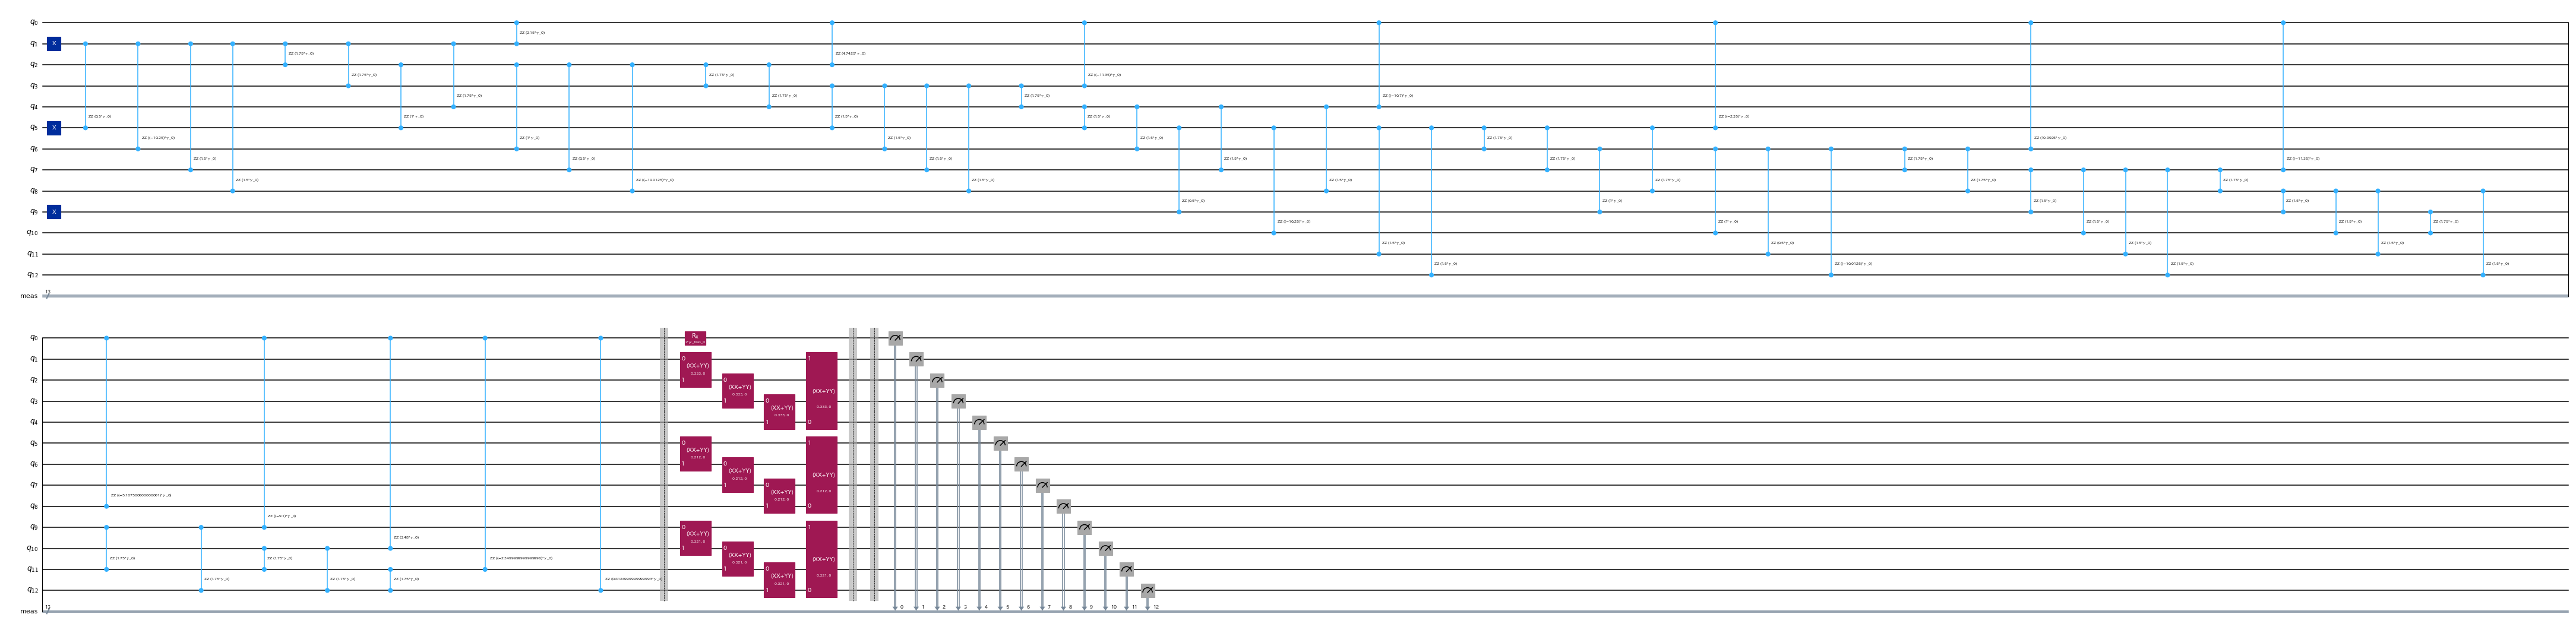


--- ISA 回路 ---


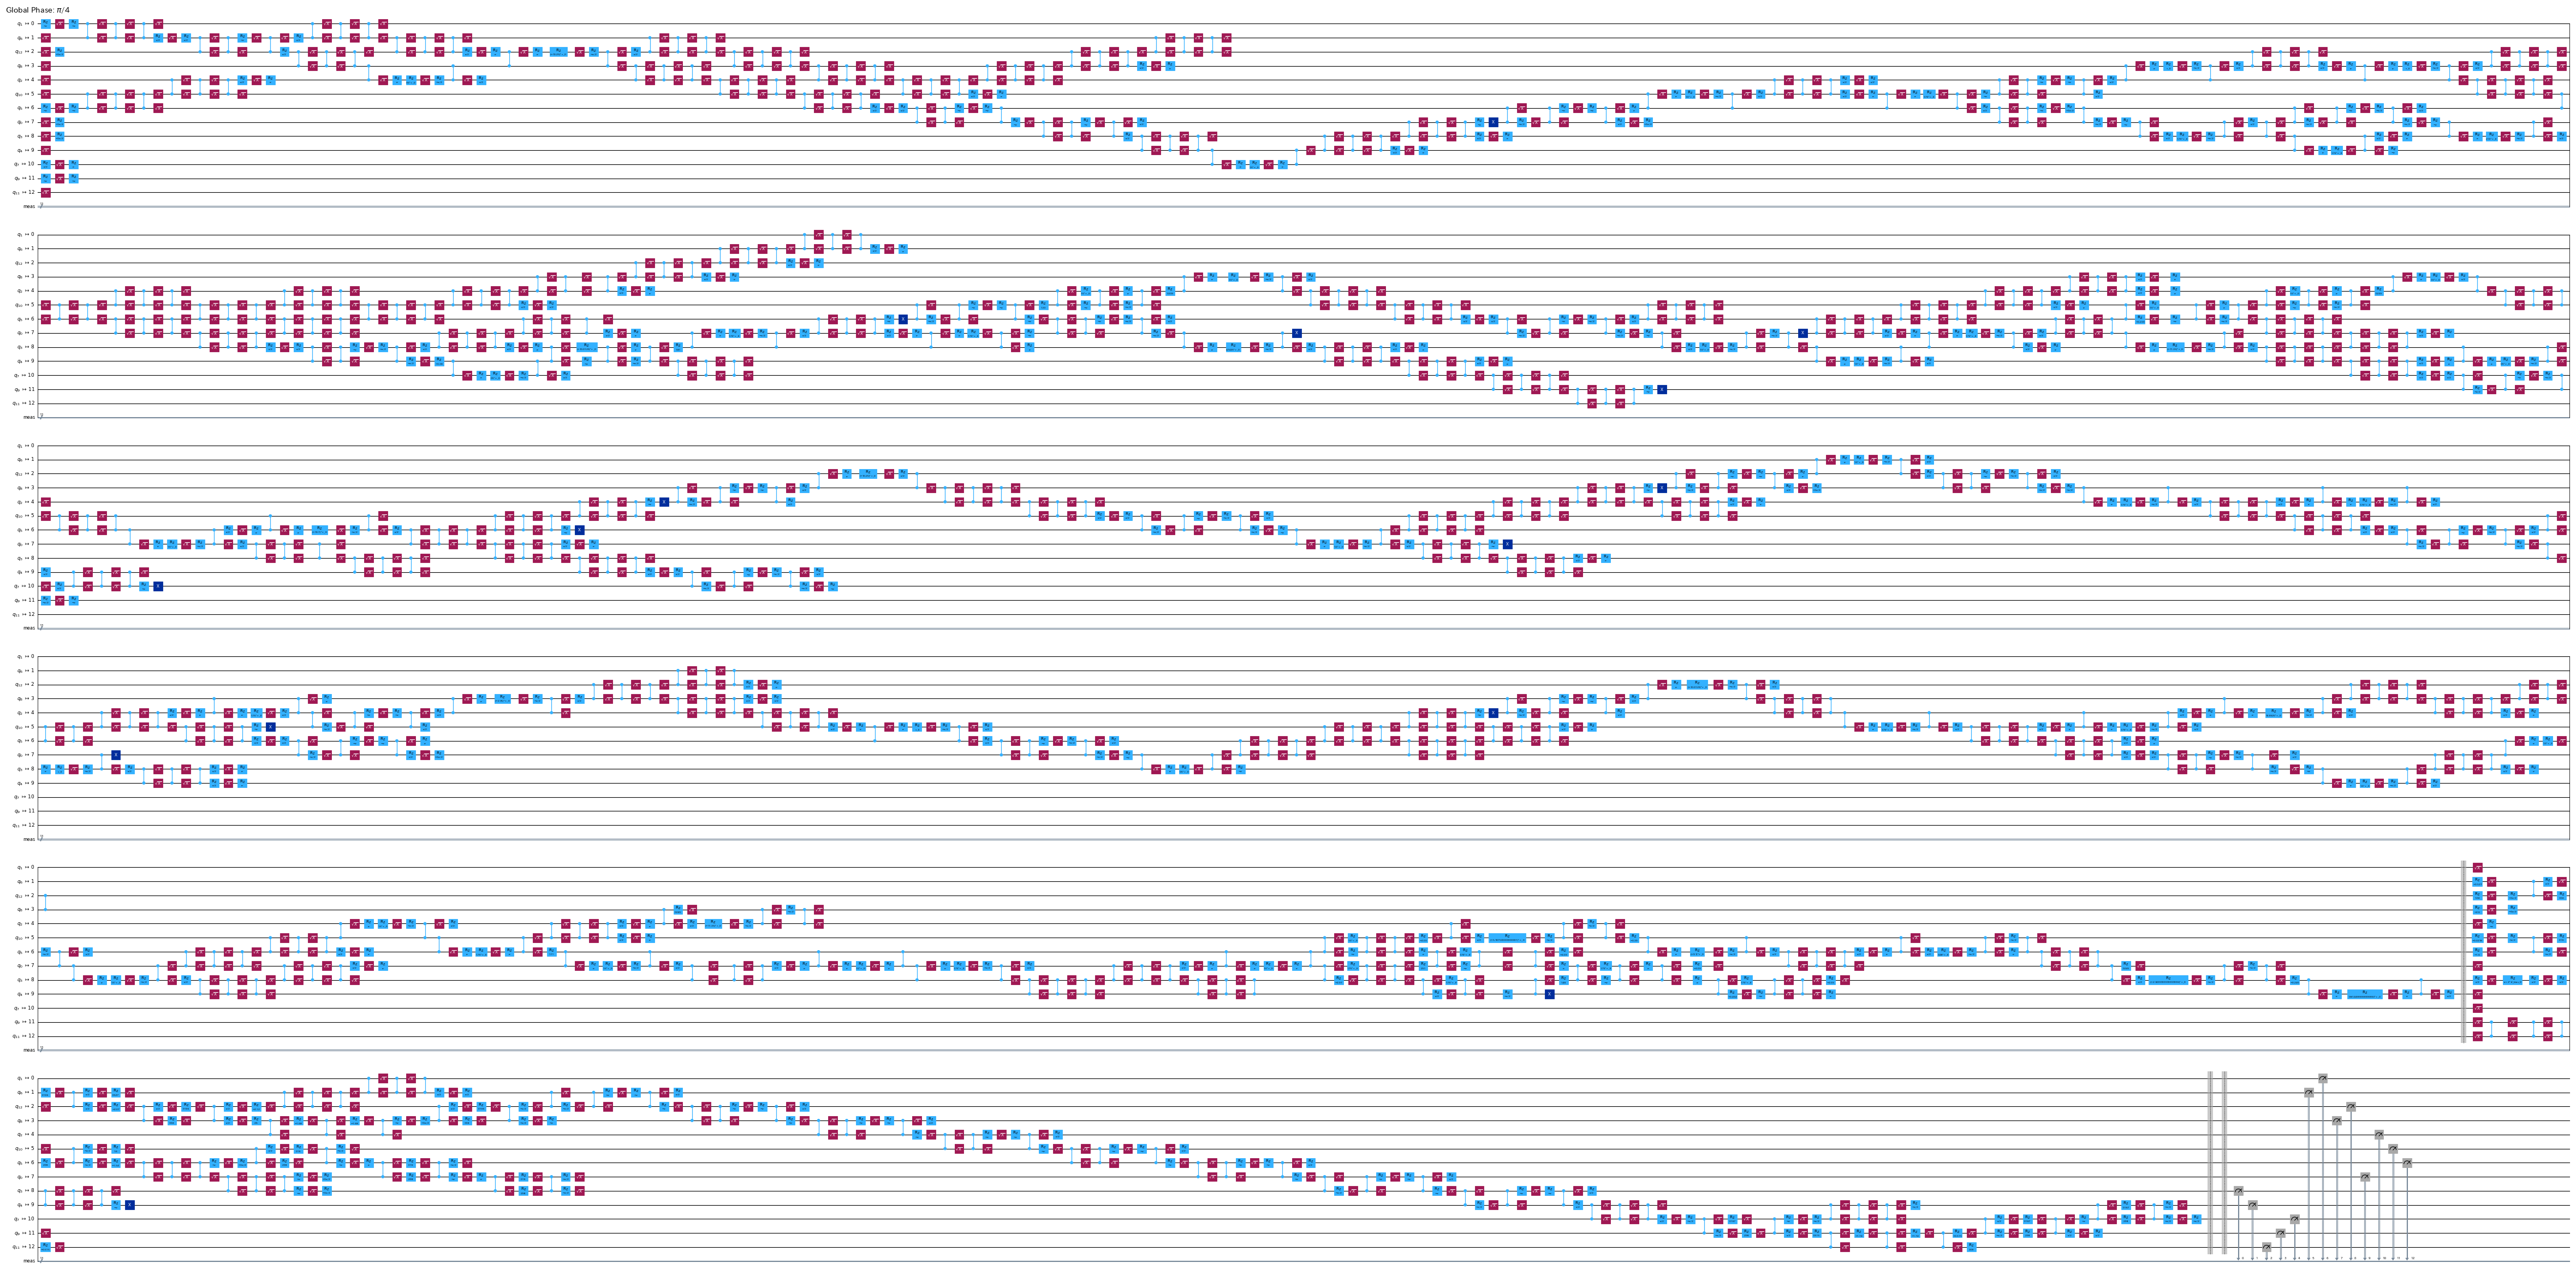

描画が完了しました。


In [ ]:
from IPython.display import display

def draw_circuits(qc_logical, qc_isa):
    print("\n--- 論理回路 ---")
    try:
        # mplで描画したFigureオブジェクトを直接display()に渡す
        fig_log = qc_logical.draw(output="mpl", fold=120, scale=0.55, style={"name": "iqp"})
        display(fig_log)
    except Exception as e:
        print(f"[plot] 論理回路描画スキップ: {e}")

    print("\n--- ISA 回路 ---")
    try:
        fig_isa = qc_isa.draw(output="mpl", fold=180, idle_wires=False, scale=0.4)
        display(fig_isa)
    except Exception as e:
        print(f"[plot] ISA 回路描画スキップ: {e}")

# 実行ブロック
def draw_circuit_only():
    print("最適化をスキップし、回路図の生成と描画のみを実行します...")

    G = build_graph()

    chaos_schedule = None
    if CHAOS_MODE in ("mixing", "both"):
        chaos_init = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R, random_seed=RANDOM_SEED)
        beta_base_for_schedule = np.linspace(0.5, 0.8, QAOA_DEPTH)
        chaos_schedule = chaotic_beta_schedule(
            p=QAOA_DEPTH, T_turns=T, beta_base=beta_base_for_schedule,
            chaos_scale=CHAOS_SCALE, chaos_initializer=chaos_init,
        )

    qc, params, param_info = build_qaoa_circuit_xy(
        G, QAOA_DEPTH, mixer_type=MIXER_TYPE, chaos_beta_schedule=chaos_schedule
    )

    backend, _, _ = get_backend_and_sampler("fake")
    isa_qc, meas_map = transpile_for_backend(
        qc, backend, use_swap_strategy=USE_SWAP_STRATEGY, graph=G
    )

    draw_circuits(qc, isa_qc)
    print("描画が完了しました。")

draw_circuit_only()

# 実機計算

### 結局シミュレータ

ショット数は3000回くらい

計算時間は18分くらい

実機だと無理かも

 壊れコンボ QAOA — カオスアトラクター統合版
  EXECUTION_MODE  = aer
  QAOA_DEPTH (p)  = 1
  MIXER_TYPE      = xy
  CHAOS_MODE      = both
  CHAOS_TYPE      = logistic
  CHAOS_R         = 3.99
  CHAOS_SCALE     = 0.4
  CHAOS_RESTARTS  = 1
  SHOTS (final)   = 3000
  CVAR_ALPHA      = 0.25

[graph] nodes=25, edges=140

[QAOA] qubits=25, depth=1, mixer=xy, chaos=both
[chaos mixing] β スケジュール (p×T = 1×6):
  layer 0: [0.666, 0.424, 0.641, 0.499, 0.699, 0.304]
[circuit] logical depth=94, 2q gates=164, n_params=2
[params]  構造: {'mixer': 'xy', 'n_bias': 1, 'n_gammas': 1, 'chaos_mixing': True, 'chaos_scale': 0.4}
論理量子ビット数: 25
[backend] AerSimulator (noiseless)
[swap] 選択的 SWAP 戦略 (シナジー辺のみ) を適用
  [selective SWAP] シナジー辺: 10 本
    chain  T0_弱 → T1_強 → T2_ｷｬﾝｾﾙ
    chain  T1_ｷｬﾝｾﾙ → T0_強
    chain  T3_ｷｬﾝｾﾙ → T2_強 → T1_弱
    chain  T2_弱 → T3_強 → T4_ｷｬﾝｾﾙ
    chain  T5_ｷｬﾝｾﾙ → T4_強 → T3_弱
    chain  T4_弱 → T5_強
  [selective SWAP] depth=98, 2q=188
[optimize] cobyla, max_iter=10, total_restarts=3
  [Normal Restart 1/2] カ

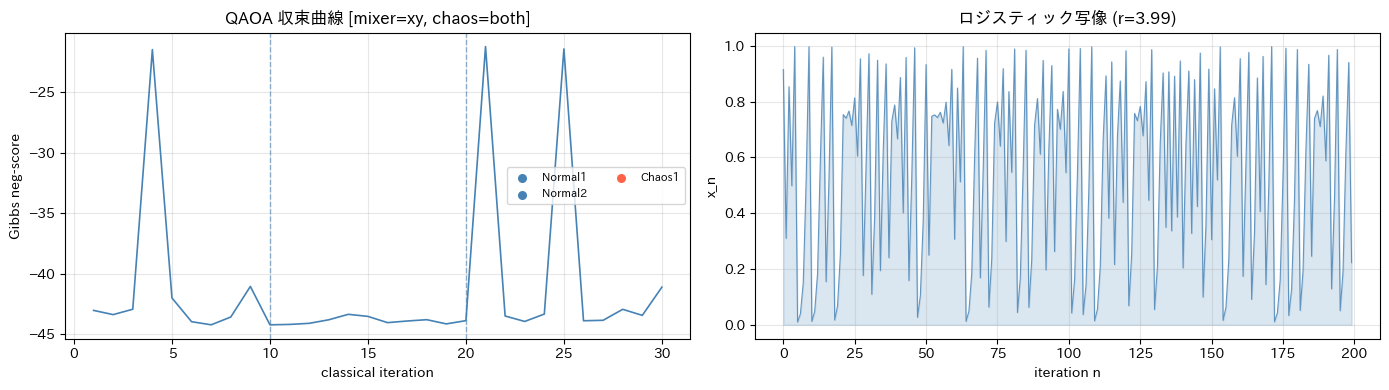

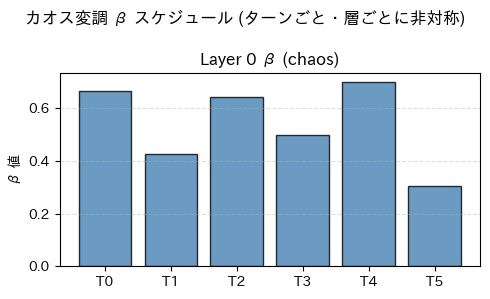

/tmp/ipykernel_1150/1693245306.py:1134: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) IPAexGothic.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


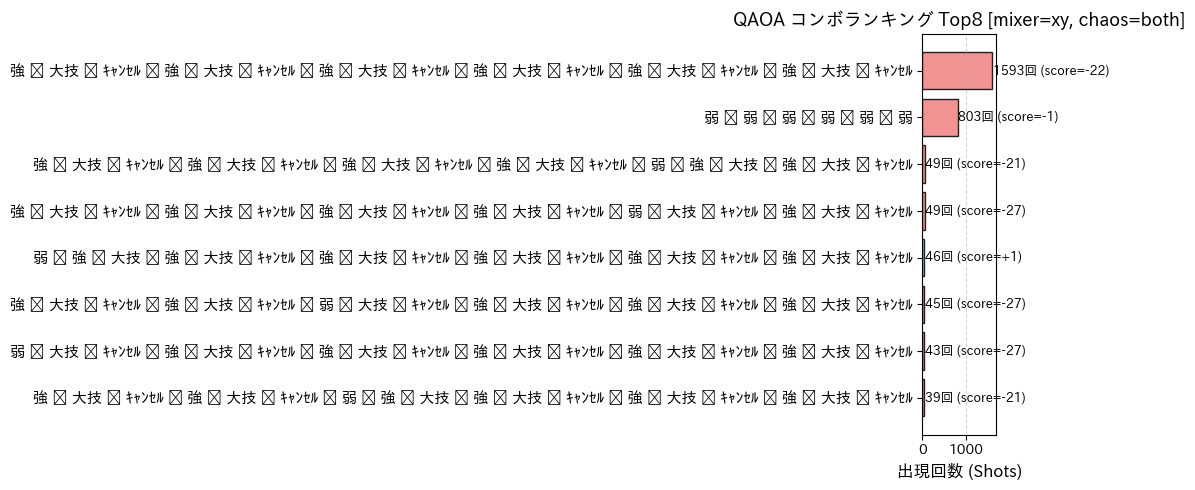


--- 論理回路 ---

--- ISA 回路 ---

=== DONE ===


In [ ]:
"""
壊れコンボ探索 QAOA — カオスアトラクター統合版
================================================

■ カオスアトラクターの統合設計
---------------------------------------------------------------------------
元コードの「XY ミキサー統合版」に、2 種類のカオス機構を追加する。

【アプローチ 1: カオス注入 (Chaotic Parameter Initialization & Perturbation)】
  ロジスティック写像 / Lorenz アトラクターのカオス時系列を
  QAOA パラメータ (β, γ) の初期値生成・再スタート時の摂動に使用する。

  従来のマルチスタート: rng.uniform で i.i.d. ランダム初期値
  → 各スタートが「独立したランダムな場所」から出発
  → 探索空間のカバレッジは確率的 (偏りが生じやすい)

  カオス注入後: ロジスティック写像 x_{n+1} = r*x_n*(1-x_n) [r=3.99]
  → 決定論的だが非周期・エルゴード的な軌道
  → 同じシード再現可能 + 空間を均等かつ密に被覆
  → 「引力盆地 (局所解) の近傍を通り過ぎても止まらず次の谷へ」

  実装: ChaosInitializer クラス
    - logistic_sequence(n): ロジスティック写像で n 個の [0,1] 値列
    - lorenz_sequence(n):   Lorenz 系の x 軸投影を [0,1] に正規化した n 個列
    - perturb(theta):       収束済みパラメータにカオス摂動を加えて局所解から脱出

【アプローチ 2: カオス・ミキシング (Chaotic Mixing Hamiltonian)】
  QAOA の β パラメータを古典最適化変数のみで決めるのではなく、
  各層・各ターンの β を「カオス時系列で変調」させる。

  通常の XY ミキサー: β_turn_t (固定スカラー) を各ターンに一様適用
  → 全ターン同じ強さで「隣接アクションへのスワップ」を誘起
  → 同じ強い局所解に集中しやすい

  カオス変調 XY ミキサー:
    β_eff_{t,l} = β_turn_{l} * (1 + chaos_scale * ξ_{t,l})
    ξ_{t,l} ~ ロジスティック写像の時系列  ([-1, +1] にスケール)
  → ターンごと・層ごとに非同期な強さでスワップを誘起
  → あるターンは「弱い遷移」、別のターンは「強い遷移」という非対称性
  → エネルギー地形上でのスクランブリング効果 → 局所解トラップ回避

  実装: chaotic_beta_schedule(p, T, beta_base, chaos_scale, chaos_r) 関数
    - p 層 × T ターン のカオス変調 β テーブルを生成
    - 回路構築時に append_xy_mixer_layer へ渡す個別 β として使用

■ 切り替え方法
---------------------------------------------------------------------------
CHAOS_MODE = "none"     → 元コードと同一 (カオスなし)
CHAOS_MODE = "inject"   → アプローチ1: カオス初期値注入のみ
CHAOS_MODE = "mixing"   → アプローチ2: カオス変調ミキシングのみ
CHAOS_MODE = "both"     → 両方統合 (推奨: 最大の多様性)

CHAOS_TYPE = "logistic" → ロジスティック写像
CHAOS_TYPE = "lorenz"   → Lorenz アトラクター

■ パラメータ
---------------------------------------------------------------------------
CHAOS_SCALE  : カオス変調の振幅 [0.0, 1.0]。0 = 無効、0.3 = 穏やか、1.0 = 最大
CHAOS_R      : ロジスティック写像の r パラメータ。3.9 < r ≤ 4.0 でカオス
CHAOS_INJECT_SCALE : 摂動の強さ (perturb)。0.1 = 小さな摂動、0.5 = 大幅ジャンプ
CHAOS_RESTARTS     : カオス摂動後の追加再スタート数

Author: Tsubasa (Chiba Inst. of Tech.) — NEDO Quantum Entry program
         カオスアトラクター統合拡張
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import XXPlusYYGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as RuntimeSamplerV2,
    Session,
)
from qiskit_ibm_runtime.fake_provider import FakeTorino

try:
    from qopt_best_practices.swap_strategies import (
        make_meas_map, apply_swap_strategy,
    )
    from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import (
        SwapStrategy,
    )
    _HAS_QOPT = True
except ImportError:
    print("[warning] qopt-best-practices が見つかりません。SWAP 戦略はスキップ。")
    _HAS_QOPT = False

try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    pass


# =============================================================================
# 1. ハイパーパラメータ
# =============================================================================
EXECUTION_MODE       = "aer"   # "aer" / "fake" / "ibm"
IBM_BACKEND_NAME     = None
IBM_CHANNEL          = "ibm_quantum_platform"
IBM_TOKEN            = ""
IBM_INSTANCE         = ""

QAOA_DEPTH           = 1       # QAOA 層数 p
SHOTS                = 3000
SHOTS_OPTIMIZE       = 3000
CLASSICAL_OPTIMIZER  = "cobyla"
MAX_ITER             = 10
NUM_RESTARTS         = 2

USE_SWAP_STRATEGY         = False
USE_DYNAMICAL_DECOUPLING  = True
USE_TWIRLING              = True
OPTIMIZATION_LEVEL        = 3
CVAR_ALPHA                = 0.25
RANDOM_SEED               = 42

USE_SELECTIVE_SWAP        = True
MIXER_TYPE = "xy"

# ── カオスアトラクター設定 ────────────────────────────────────────────────────
# CHAOS_MODE:
#   "none"    → カオス無効 (元コードと同一)
#   "inject"  → アプローチ1: カオス初期値注入 (パラメータ初期化 + 摂動)
#   "mixing"  → アプローチ2: カオス変調ミキシング (β の時変)
#   "both"    → 両方統合 (推奨)
CHAOS_MODE           = "both"

# CHAOS_TYPE:
#   "logistic" → ロジスティック写像 (軽量・高速)
#   "lorenz"   → Lorenz アトラクター (より複雑な軌道)
CHAOS_TYPE           = "logistic"

# ロジスティック写像パラメータ (3.9 < r <= 4.0 でカオス領域)
CHAOS_R              = 3.99

# カオス変調ミキシングの振幅 (0.0=無効, 0.3=穏やか, 1.0=最大変調)
CHAOS_SCALE          = 0.4

# カオス初期値注入の追加再スタート数 (CHAOS_MODE in ("inject","both") で有効)
CHAOS_RESTARTS       = 1

# カオス摂動の強さ (元の best パラメータからのジャンプ幅の倍率)
CHAOS_INJECT_SCALE   = 0.35

np.random.seed(RANDOM_SEED)


# =============================================================================
# 2. ゲームバランス定義 (元コードと同一)
# =============================================================================
BOSS_HP      = 50.0
BASE_REWARD  = 0.5

ACTIONS = {
    0: {"name": "弱",     "damage": 0.15, "kill_prob": 0.00},
    1: {"name": "強",     "damage": 1.00, "kill_prob": 0.02},
    2: {"name": "大技",   "damage": 2.00, "kill_prob": 0.05},
    3: {"name": "ｷｬﾝｾﾙ", "damage": 0.05, "kill_prob": 0.00},
}

T        = 6
LAMBDA_1 = 3.5
LAMBDA_2 = 1.0
SYNERGY_BONUS = 20.0

penalty_matrix = {
    0: {0: 1, 1: 0, 2: 3, 3: 3},
    1: {0: 2, 1: 2, 2: 1, 3: 0},
    2: {0: 3, 1: 3, 2: 3, 3: 3},
    3: {0: 3, 1: 3, 2: 3, 3: 3},
}

def get_timing_bonus(t, action_name):
    if action_name == "大技" and t == 0:
        return -5.0
    if action_name == "大技" and t == T - 1:
        return 3.0
    return 0.0


# =============================================================================
# 3. グラフ構築 (元コードと同一)
# =============================================================================
def build_graph():
    G = nx.Graph()
    G.add_node("Bias", layer=0)
    for t in range(T):
        for a, info in ACTIONS.items():
            node_name = f"T{t}_{info['name']}"
            p_kill    = info["kill_prob"]
            exp_damage = (p_kill * BOSS_HP) + ((1.0 - p_kill) * info["damage"])
            timing_bonus = get_timing_bonus(t, info["name"])
            w = exp_damage + BASE_REWARD + timing_bonus
            G.add_edge("Bias", node_name, weight=w)

    for t in range(T - 1):
        for a in ACTIONS.keys():
            for b in ACTIONS.keys():
                gap = penalty_matrix[a][b]
                u = f"T{t}_{ACTIONS[a]['name']}"
                v = f"T{t+1}_{ACTIONS[b]['name']}"
                if gap > 0:
                    G.add_edge(u, v, weight=-LAMBDA_2 * gap)
                else:
                    G.add_edge(u, v, weight=SYNERGY_BONUS + ACTIONS[b]['damage'] * 0.5)

    for t in range(T):
        actions_list = list(ACTIONS.keys())
        for i in range(len(actions_list)):
            for j in range(i + 1, len(actions_list)):
                u = f"T{t}_{ACTIONS[actions_list[i]]['name']}"
                v = f"T{t}_{ACTIONS[actions_list[j]]['name']}"
                G.add_edge(u, v, weight=-LAMBDA_1)
    return G


# =============================================================================
# 4. カオスアトラクター — 決定論的乱数源
# =============================================================================

class ChaosInitializer:
    """
    ロジスティック写像 / Lorenz アトラクターによるカオス時系列生成器。

    主な用途:
      1. QAOA パラメータ初期値のカオス生成 (アプローチ 1: カオス注入)
      2. ミキサーの β スケジュール生成 (アプローチ 2: カオス変調)
      3. 収束済みパラメータへの摂動 (局所解脱出)

    特性:
      - 決定論的 (seed 固定で完全再現可能)
      - エルゴード的 (無限軌道が空間を均等に被覆)
      - 非周期的 (周期に捕まらずに探索)
    """

    def __init__(self, chaos_type: str = "logistic", r: float = 3.99,
                 seed: float = None, random_seed: int = 42):
        """
        Parameters
        ----------
        chaos_type : "logistic" または "lorenz"
        r          : ロジスティック写像の r パラメータ (3.9 < r <= 4.0 でカオス)
        seed       : ロジスティック写像の初期値 x_0 ∈ (0, 1)
                     None の場合は random_seed から自動決定
        random_seed: numpy random seed (seed が None のときに使用)
        """
        self.chaos_type = chaos_type
        self.r          = r
        if seed is None:
            rng  = np.random.default_rng(random_seed)
            seed = rng.uniform(0.01, 0.99)
        self.x0 = float(seed)
        self._lorenz_cache = None  # Lorenz 軌道キャッシュ

    # ── ロジスティック写像 ────────────────────────────────────────────────────
    def logistic_sequence(self, n: int, warmup: int = 200) -> np.ndarray:
        """
        ロジスティック写像で n 個の値列を生成する。

        x_{n+1} = r * x_n * (1 - x_n)

        warmup 回で過渡応答を除いてからサンプリングするため、
        初期値への依存性が排除されカオス的定常軌道を得る。

        Returns
        -------
        values : shape (n,), 値域 (0, 1) のカオス時系列
        """
        x = self.x0
        for _ in range(warmup):
            x = self.r * x * (1.0 - x)
        seq = np.empty(n)
        for i in range(n):
            x = self.r * x * (1.0 - x)
            seq[i] = x
        return seq

    # ── Lorenz アトラクター ────────────────────────────────────────────────────
    def _lorenz_ode(self, t, state, sigma=10.0, rho=28.0, beta_l=8.0/3.0):
        """Lorenz 系の右辺: dx/dt, dy/dt, dz/dt"""
        x, y, z = state
        return [
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta_l * z,
        ]

    def lorenz_sequence(self, n: int, dt: float = 0.01,
                        warmup_steps: int = 1000) -> np.ndarray:
        """
        Lorenz アトラクターの x 軸投影を [0,1] に正規化した n 個列。

        sigma=10, rho=28, beta=8/3 の古典パラメータでカオス的振る舞い。
        warmup_steps 分だけ積分して過渡応答を除去する。

        Returns
        -------
        values : shape (n,), 値域 [0, 1] に正規化済み
        """
        t_end  = (warmup_steps + n) * dt
        t_eval = np.linspace(warmup_steps * dt, t_end, n)
        sol    = solve_ivp(
            self._lorenz_ode,
            t_span=(0.0, t_end),
            y0   =[self.x0 * 20 - 10, self.x0 * 20 - 10, 25.0],
            t_eval=t_eval,
            method="RK45",
            rtol=1e-8,
        )
        xs = sol.y[0]  # x 軸成分 (定常アトラクター上)
        # [0,1] に正規化
        lo, hi = xs.min(), xs.max()
        if hi > lo:
            return (xs - lo) / (hi - lo)
        return np.full(n, 0.5)

    def get_sequence(self, n: int) -> np.ndarray:
        """chaos_type に応じて時系列を返す統一インターフェース。"""
        if self.chaos_type == "lorenz":
            return self.lorenz_sequence(n)
        else:
            return self.logistic_sequence(n)

    # ── カオス初期値生成 (アプローチ 1) ─────────────────────────────────────
    def make_init_params(
        self,
        n_betas: int,
        n_gammas: int,
        mixer_type: str,
        beta_lo: float = 0.1,
        beta_hi: float = np.pi,
        gamma_lo: float = -0.5,
        gamma_hi: float = 0.5,
        restart_idx: int = 0,
    ) -> np.ndarray:
        """
        QAOA パラメータの初期値をカオス時系列から生成する。

        各 restart_idx ごとに warmup をずらして、
        再スタートごとに異なる軌道区間を使用する。

        Parameters
        ----------
        restart_idx : 再スタート番号 (0, 1, 2, ...) → warmup をずらす

        Returns
        -------
        x0 : shape (n_betas + n_gammas,)
        """
        total    = n_betas + n_gammas
        # restart_idx に応じて warmup をずらす (ずらし量: 100 * idx)
        extra_warmup = restart_idx * 100
        if self.chaos_type == "lorenz":
            seq = self.lorenz_sequence(total, warmup_steps=1000 + extra_warmup)
        else:
            seq = self.logistic_sequence(total, warmup=200 + extra_warmup)

        # β: [beta_lo, beta_hi] にスケール
        betas  = seq[:n_betas]  * (beta_hi - beta_lo) + beta_lo
        # γ: [gamma_lo, gamma_hi] にスケール
        gammas = seq[n_betas:] * (gamma_hi - gamma_lo) + gamma_lo
        return np.concatenate([betas, gammas])

    # ── カオス摂動 (局所解脱出) ───────────────────────────────────────────────
    def perturb(
        self,
        theta: np.ndarray,
        inject_scale: float = 0.3,
        restart_idx: int = 0,
    ) -> np.ndarray:
        """
        最適化済みパラメータ theta にカオス摂動を加えて局所解から脱出する。

        摂動量 δ = inject_scale * scale * (ξ - 0.5) * 2
          ξ : カオス時系列 [0,1]
          scale : theta の標準偏差 (パラメータスケールに適応)

        全要素が同方向にシフトするのではなく、
        カオス軌道の非相関性により各次元が独立した方向へ摂動される。

        Returns
        -------
        perturbed_theta : theta + δ
        """
        n   = len(theta)
        seq = self.get_sequence(n + restart_idx * n)
        seq = seq[restart_idx * n:]  # 軌道をずらす

        scale = np.std(theta) if np.std(theta) > 1e-6 else 0.3
        delta = inject_scale * scale * (seq - 0.5) * 2.0
        return theta + delta


# =============================================================================
# 5. カオス変調 β スケジュール (アプローチ 2: カオス・ミキシング)
# =============================================================================

def chaotic_beta_schedule(
    p: int,
    T_turns: int,
    beta_base: np.ndarray,
    chaos_scale: float = 0.3,
    chaos_initializer: ChaosInitializer = None,
) -> np.ndarray:
    """
    QAOA の β パラメータをカオス変調した 2D スケジュールを生成する。

    β_eff_{t,l} = β_base[l] * (1 + chaos_scale * ξ_{t,l})
    ξ_{t,l} ∈ [-1, +1]  (カオス時系列を [-1,1] にスケール)

    設計思想:
      通常の XY ミキサーは全ターン・全層で同じ β を使う
      → 探索が均質になり強い局所解へ集中しやすい

      カオス変調ではターンごと・層ごとに β が非同期に変化する
      → 各タイムステップで「どの遷移が強化されるか」が変わる
      → スクランブリング効果 → 局所解からの離脱が促進される

    Parameters
    ----------
    p          : QAOA 層数
    T_turns    : ターン数 (各層で T_turns 個の β を生成)
    beta_base  : shape (p,) 各層のベース β 値
    chaos_scale: カオス変調の振幅 [0, 1]。0 = 無変調
    chaos_initializer: None の場合はデフォルト設定で生成

    Returns
    -------
    beta_schedule : shape (p, T_turns)
                    beta_schedule[l][t] = 層 l、ターン t の有効 β
    """
    if chaos_initializer is None:
        chaos_initializer = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R)

    total = p * T_turns
    seq   = chaos_initializer.get_sequence(total)
    # [0,1] → [-1,+1]
    xi    = (seq - 0.5) * 2.0
    xi    = xi.reshape(p, T_turns)

    schedule = np.zeros((p, T_turns))
    for l in range(p):
        bl = beta_base[l] if l < len(beta_base) else beta_base[-1]
        schedule[l] = bl * (1.0 + chaos_scale * xi[l])
        # β が負にならないよう clip (XY ゲートに負 θ を渡すと逆方向スワップになる)
        schedule[l] = np.clip(schedule[l], 1e-4, None)

    return schedule


# =============================================================================
# 6. XY ミキサー補助関数 (元コードと同一)
# =============================================================================
def extract_synergy_edges(graph: nx.Graph) -> list[tuple[int, int, float]]:
    node_to_q = {node: i for i, node in enumerate(graph.nodes())}
    syn = []
    for u, v, d in graph.edges(data=True):
        if u == "Bias" or v == "Bias":
            continue
        tu, tv = int(u[1]), int(v[1])
        if tu != tv and d["weight"] > 0:
            syn.append((node_to_q[u], node_to_q[v], d["weight"]))
    return syn


def synergy_chains(syn_edges: list[tuple[int, int, float]]) -> list[list[int]]:
    G_syn = nx.Graph()
    for qu, qv, _ in syn_edges:
        G_syn.add_edge(qu, qv)
    chains = []
    for comp in nx.connected_components(G_syn):
        subg   = G_syn.subgraph(comp)
        leaves = [n for n in subg.nodes() if subg.degree(n) == 1]
        if len(leaves) >= 2:
            path = nx.shortest_path(subg, leaves[0], leaves[-1])
        else:
            path = list(comp)
        chains.append(path)
    return chains


def apply_selective_swap(
    qc: QuantumCircuit,
    graph: nx.Graph,
    backend,
    optimization_level: int = 3,
) -> tuple[QuantumCircuit, dict[int, int]]:
    n         = qc.num_qubits
    node_list = list(graph.nodes())
    syn_edges = extract_synergy_edges(graph)
    chains    = synergy_chains(syn_edges)

    print(f"  [selective SWAP] シナジー辺: {len(syn_edges)} 本")
    for ch in chains:
        names = [node_list[q] for q in ch]
        print(f"    chain  {' → '.join(names)}")

    syn_qubits = []
    for ch in chains:
        for q in ch:
            if q not in syn_qubits:
                syn_qubits.append(q)
    non_syn        = [q for q in range(n) if q not in syn_qubits]
    suggested_order = syn_qubits + non_syn

    qregs          = qc.qubits
    initial_layout = {qregs[logical]: phys
                      for phys, logical in enumerate(suggested_order)}
    try:
        pm     = generate_preset_pass_manager(
            optimization_level=optimization_level,
            backend=backend,
            initial_layout=initial_layout,
        )
        isa_qc = pm.run(qc)
        print(f"  [selective SWAP] depth={isa_qc.depth()}, "
              f"2q={isa_qc.num_nonlocal_gates()}")
    except Exception as e:
        print(f"  [selective SWAP] 適用失敗 ({e}), 通常 transpile へ")
        pm     = generate_preset_pass_manager(
            optimization_level=optimization_level, backend=backend)
        isa_qc = pm.run(qc)

    meas_map = {i: i for i in range(n)}
    return isa_qc, meas_map


def generate_xy_pairs(qubit_indices: list[int], case: str = "ring") -> list[list[int]]:
    n = len(qubit_indices)
    if n < 2:
        return []
    pairs = [[qubit_indices[i], qubit_indices[i + 1]] for i in range(n - 1)]
    if case == "ring":
        pairs.append([qubit_indices[n - 1], qubit_indices[0]])
    return pairs


def append_xy_mixer_layer(
    qc: QuantumCircuit,
    qubit_groups: list[list[int]],
    bias_qubit: int,
    beta_bias: Parameter,
    beta_turns: list,          # Parameter または float (カオス変調時は float)
    case: str = "ring",
    beta_cross: list = None,
    cross_pairs: list[list[int]] = None,
):
    """
    XY ミキサー層を回路に追加する。

    beta_turns に float リストが渡された場合 (カオス変調モード) は
    Parameter ではなく数値として直接 XXPlusYYGate に渡す。
    """
    qc.rx(2.0 * beta_bias, bias_qubit)

    for g_idx, group in enumerate(qubit_groups):
        pairs = generate_xy_pairs(group, case=case)
        beta  = beta_turns[g_idx]  # Parameter or float
        for pair in pairs:
            qc.append(XXPlusYYGate(0.5 * beta), [pair[0], pair[1]])

    if beta_cross is not None and cross_pairs is not None:
        for cp_idx, cp in enumerate(cross_pairs):
            if cp_idx < len(beta_cross):
                qc.rx(2.0 * beta_cross[cp_idx], cp[0])
                qc.rx(2.0 * beta_cross[cp_idx], cp[1])


# =============================================================================
# 7. QAOA 回路構築 — カオス変調対応版
# =============================================================================
def build_qaoa_circuit_xy(
    graph: nx.Graph,
    p: int,
    mixer_type: str = "xy",
    chaos_beta_schedule: np.ndarray = None,
):
    """
    カオス変調対応の QAOA 回路を構築する。

    Parameters
    ----------
    chaos_beta_schedule : shape (p, T) の float 配列 (アプローチ2 用)
                          None の場合は通常の Parameter を使用
    """
    n         = graph.number_of_nodes()
    node_list = list(graph.nodes())
    node_to_q = {node: i for i, node in enumerate(node_list)}

    bias_qubit  = node_to_q["Bias"]
    turn_groups = []
    for t in range(T):
        group = [node_to_q[f"T{t}_{ACTIONS[a]['name']}"] for a in sorted(ACTIONS.keys())]
        turn_groups.append(group)

    xy_case = "chain" if mixer_type == "xy_chain" else "ring"

    # コスト層パラメータ (常に最適化変数)
    gammas = [Parameter(f"γ_{l}") for l in range(p)]

    if mixer_type == "x":
        betas_flat = [Parameter(f"β_{l}") for l in range(p)]
        all_params = betas_flat + gammas
        param_info = {"mixer": "x", "n_betas": p, "n_gammas": p,
                      "chaos_mixing": False}

    elif mixer_type in ("xy", "xy_chain"):
        betas_bias  = [Parameter(f"β_bias_{l}") for l in range(p)]

        if chaos_beta_schedule is not None:
            # カオス変調モード: ターン β は固定数値 (最適化変数ではない)
            betas_turns = [[float(chaos_beta_schedule[l, t]) for t in range(T)]
                           for l in range(p)]
            all_params  = betas_bias + gammas
            param_info  = {"mixer": mixer_type, "n_bias": p,
                           "n_gammas": p, "chaos_mixing": True,
                           "chaos_scale": CHAOS_SCALE}
        else:
            # 通常モード: ターン β は最適化変数
            betas_turns = [[Parameter(f"β_T{t}_{l}") for t in range(T)]
                           for l in range(p)]
            all_params  = (betas_bias
                           + [b for layer in betas_turns for b in layer]
                           + gammas)
            param_info  = {"mixer": mixer_type, "n_bias": p,
                           "n_turns": p * T, "n_gammas": p,
                           "chaos_mixing": False}

    elif mixer_type == "hybrid":
        betas_bias  = [Parameter(f"β_bias_{l}") for l in range(p)]
        betas_cross = [[Parameter(f"β_cross_{t}_{l}") for t in range(T - 1)]
                       for l in range(p)]
        cross_pairs = [[turn_groups[t][-1], turn_groups[t + 1][0]]
                       for t in range(T - 1)]

        if chaos_beta_schedule is not None:
            betas_turns = [[float(chaos_beta_schedule[l, t]) for t in range(T)]
                           for l in range(p)]
            all_params  = (betas_bias
                           + [b for layer in betas_cross for b in layer]
                           + gammas)
            param_info  = {"mixer": "hybrid", "n_bias": p,
                           "n_cross": p * (T-1), "n_gammas": p,
                           "chaos_mixing": True}
        else:
            betas_turns = [[Parameter(f"β_T{t}_{l}") for t in range(T)]
                           for l in range(p)]
            all_params  = (betas_bias
                           + [b for layer in betas_turns for b in layer]
                           + [b for layer in betas_cross for b in layer]
                           + gammas)
            param_info  = {"mixer": "hybrid", "n_bias": p,
                           "n_turns": p * T, "n_cross": p * (T-1),
                           "n_gammas": p, "chaos_mixing": False}
    else:
        raise ValueError(f"Unknown mixer_type: {mixer_type!r}")

    # ── 回路構築 ────────────────────────────────────────────────────────────
    qreg = QuantumRegister(n, name="q")
    qc   = QuantumCircuit(qreg, name=f"QAOA-{mixer_type}")



    # 初期状態
    if mixer_type in ("xy", "xy_chain", "hybrid"):
        for t in range(T):
            qc.x(turn_groups[t][0])
    else:
        qc.h(range(n))

    for layer in range(p):
        # コスト層
        for u, v in graph.edges():
            if u != "Bias" and v != "Bias":
                w    = graph[u][v]["weight"]
                coef = -w / 4.0
                qc.rzz(2.0 * gammas[layer] * coef,
                        node_to_q[u], node_to_q[v])

        for node in graph.nodes():
            if node != "Bias":
                D_i   = (graph["Bias"][node]["weight"]
                         if graph.has_edge("Bias", node) else 0.0)
                sum_P = sum(graph[node][nb]["weight"]
                            for nb in graph.neighbors(node) if nb != "Bias")
                coef  = D_i / 2.0 + sum_P / 4.0
                qc.rzz(2.0 * gammas[layer] * coef,
                        node_to_q["Bias"], node_to_q[node])
        qc.barrier()

        # ミキサー層
        if mixer_type == "x":
            for i in range(n):
                qc.rx(2.0 * betas_flat[layer], i)
        elif mixer_type in ("xy", "xy_chain"):
            append_xy_mixer_layer(
                qc,
                qubit_groups = turn_groups,
                bias_qubit   = bias_qubit,
                beta_bias    = betas_bias[layer],
                beta_turns   = betas_turns[layer],
                case         = xy_case,
            )
        elif mixer_type == "hybrid":
            append_xy_mixer_layer(
                qc,
                qubit_groups = turn_groups,
                bias_qubit   = bias_qubit,
                beta_bias    = betas_bias[layer],
                beta_turns   = betas_turns[layer],
                case         = "ring",
                beta_cross   = betas_cross[layer],
                cross_pairs  = cross_pairs,
            )
        qc.barrier()

    qc.measure_all()
    return qc, all_params, param_info


# =============================================================================
# 8. backend と sampler の準備 (元コードと同一)
# =============================================================================
def get_backend_and_sampler(mode):
    session = None
    if mode == "aer":
        backend = AerSimulator()
        sampler = BackendSamplerV2(backend=backend)
        print("[backend] AerSimulator (noiseless)")
    elif mode == "fake":
        backend = FakeTorino()
        sampler = BackendSamplerV2(backend=backend)
        print("[backend] FakeTorino (noisy simulator)")
    elif mode == "ibm":
        try:
            service = QiskitRuntimeService(
                channel=IBM_CHANNEL, token=IBM_TOKEN, instance=IBM_INSTANCE)
        except Exception:
            service = QiskitRuntimeService()
        backend = (service.backend(IBM_BACKEND_NAME) if IBM_BACKEND_NAME
                   else service.least_busy(min_num_qubits=17,
                                           operational=True, simulator=False))
        print(f"[backend] IBM real hardware: {backend.name}")
        session = Session(backend=backend)
        sampler = RuntimeSamplerV2(mode=session)
        sampler.options.default_shots = SHOTS_OPTIMIZE
        if USE_DYNAMICAL_DECOUPLING:
            sampler.options.dynamical_decoupling.enable = True
            sampler.options.dynamical_decoupling.sequence_type = "XY4"
        if USE_TWIRLING:
            sampler.options.twirling.enable_gates   = True
            sampler.options.twirling.enable_measure = True
    else:
        raise ValueError(f"Unknown EXECUTION_MODE: {mode}")
    return backend, sampler, session


# =============================================================================
# 9. transpile (元コードと同一)
# =============================================================================
def transpile_for_backend(qc, backend, use_swap_strategy=True, graph=None):
    if USE_SELECTIVE_SWAP and graph is not None:
        print("[swap] 選択的 SWAP 戦略 (シナジー辺のみ) を適用")
        return apply_selective_swap(qc, graph, backend, OPTIMIZATION_LEVEL)

    if use_swap_strategy and _HAS_QOPT:
        try:
            n = qc.num_qubits
            swap_strategy = SwapStrategy.from_line(list(range(n)))
            edge_coloring = {(i, i + 1): (i + 1) % 2 for i in range(n - 1)}
            qc_swapped    = apply_swap_strategy(qc, swap_strategy, edge_coloring)
            meas_map      = make_meas_map(qc_swapped)
            print("[swap] 全辺線形 SWAP 戦略を適用 (全 qubit)")
        except Exception as e:
            print(f"[swap] strategy failed ({e}), 通常 transpile に切り替え")
            qc_swapped = qc
            meas_map   = {i: i for i in range(qc.num_qubits)}
    else:
        qc_swapped = qc
        meas_map   = {i: i for i in range(qc.num_qubits)}

    pm     = generate_preset_pass_manager(
        optimization_level=OPTIMIZATION_LEVEL, backend=backend)
    isa_qc = pm.run(qc_swapped)
    print(f"[transpile] depth={isa_qc.depth()}, 2q gates={isa_qc.num_nonlocal_gates()}")
    return isa_qc, meas_map


# =============================================================================
# 10. counts 解釈 (元コードと同一)
# =============================================================================
def remap_counts(raw_counts, meas_map, n_qubits, node_list):
    new_counts = {}
    for bs, cnt in raw_counts.items():
        phys_bits    = bs[::-1]
        logical_bits = ["0"] * n_qubits
        for lq, cb in meas_map.items():
            if cb < len(phys_bits):
                logical_bits[lq] = phys_bits[cb]
        new_bs = "".join(logical_bits)
        new_counts[new_bs] = new_counts.get(new_bs, 0) + cnt
    return new_counts


# =============================================================================
# 11. 評価関数
# =============================================================================
def compute_score(counts, graph, node_list):
    total    = sum(counts.values())
    expected = 0.0
    for bs, cnt in counts.items():
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        score = sum(graph["Bias"][node]["weight"] for node in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    score += graph[u][v]["weight"]
        expected += score * (cnt / total)
    return -expected


def cvar_score(counts, graph, node_list, alpha):
    total = sum(counts.values())
    rows  = []
    for bs, cnt in counts.items():
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        s = sum(graph["Bias"][node]["weight"] for node in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    s += graph[u][v]["weight"]
        rows.append((-s, cnt / total))
    rows.sort(key=lambda r: r[0])
    cum, used = 0.0, []
    for e, w in rows:
        if cum + w >= alpha:
            used.append((e, alpha - cum))
            break
        used.append((e, w))
        cum += w
    if not used:
        return 0.0
    total_w = sum(w for _, w in used)
    return sum(e * w for e, w in used) / total_w


def gibbs_score(counts, graph, node_list, eta=1.0):
    """Gibbs/Boltzmann 重み付きスコア (カオス統合版でも使用)"""
    total = sum(counts.values())
    rows  = []
    for bs, cnt in counts.items():
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        s = sum(graph["Bias"][node]["weight"] for node in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    s += graph[u][v]["weight"]
        rows.append((-s, cnt / total))

    if not rows:
        return 0.0
    energies = np.array([e for e, _ in rows])
    weights  = np.array([w for _, w in rows])
    e_min    = energies.min()
    boltz    = np.exp(-eta * (energies - e_min))
    boltz   /= (boltz * weights).sum()
    return float((energies * boltz * weights).sum())


# =============================================================================
# 12. メイン QAOA ループ — カオスアトラクター統合版
# =============================================================================
def run_qaoa(graph: nx.Graph, mixer_type: str = MIXER_TYPE,
             chaos_mode: str = CHAOS_MODE):
    """
    カオスアトラクター統合 QAOA の実行関数。

    chaos_mode:
      "none"   → 元コードと同一
      "inject" → アプローチ1: カオス初期値注入 (マルチスタートの多様性向上)
      "mixing" → アプローチ2: カオス変調ミキシング (β の時変化)
      "both"   → 両方統合 (推奨)
    """
    n         = graph.number_of_nodes()
    node_list = list(graph.nodes())
    print(f"\n[QAOA] qubits={n}, depth={QAOA_DEPTH}, mixer={mixer_type}, "
          f"chaos={chaos_mode}")

    # ── カオス初期化器の準備 ──────────────────────────────────────────────
    chaos_init = ChaosInitializer(
        chaos_type  = CHAOS_TYPE,
        r           = CHAOS_R,
        random_seed = RANDOM_SEED,
    )

    # ── アプローチ2: カオス β スケジュールの生成 ─────────────────────────
    chaos_schedule = None
    if chaos_mode in ("mixing", "both"):
        # ベース β は [0.5, 0.8] の範囲 (ターン間の変調を受ける前の基準値)
        beta_base_for_schedule = np.linspace(0.5, 0.8, QAOA_DEPTH)
        chaos_schedule = chaotic_beta_schedule(
            p              = QAOA_DEPTH,
            T_turns        = T,
            beta_base      = beta_base_for_schedule,
            chaos_scale    = CHAOS_SCALE,
            chaos_initializer = chaos_init,
        )
        print(f"[chaos mixing] β スケジュール (p×T = {QAOA_DEPTH}×{T}):")
        for l in range(QAOA_DEPTH):
            vals = ", ".join(f"{v:.3f}" for v in chaos_schedule[l])
            print(f"  layer {l}: [{vals}]")

    # ── 回路構築 ──────────────────────────────────────────────────────────
    qc, params, param_info = build_qaoa_circuit_xy(
        graph, QAOA_DEPTH, mixer_type, chaos_beta_schedule=chaos_schedule)
    print(f"[circuit] logical depth={qc.depth()}, "
          f"2q gates={qc.num_nonlocal_gates()}, "
          f"n_params={len(params)}")
    print(f"[params]  構造: {param_info}")




        # ★ ここで量子ビット数を出力 ★
    print(f"論理量子ビット数: {qc.num_qubits}")







    # ── backend / sampler ─────────────────────────────────────────────────
    backend, sampler, session = get_backend_and_sampler(EXECUTION_MODE)

    # ── transpile ────────────────────────────────────────────────────────
    isa_qc, meas_map = transpile_for_backend(
        qc, backend, use_swap_strategy=USE_SWAP_STRATEGY, graph=graph)

    # ── パラメータ次元の確認 ──────────────────────────────────────────────
    n_params = len(params)
    n_gammas = QAOA_DEPTH
    n_betas  = n_params - n_gammas

    convergence = []
    best_scores_per_restart = []  # 可視化用: 各再スタートの最良スコア履歴

    def cost_fn(theta):
        bound  = isa_qc.assign_parameters(dict(zip(params, theta)))
        job    = (sampler.run([(bound,)]) if EXECUTION_MODE == "ibm"
                  else sampler.run([bound], shots=SHOTS_OPTIMIZE))
        raw    = job.result()[0].data.meas.get_counts()
        counts = remap_counts(raw, meas_map, n, node_list)
        c      = gibbs_score(counts, graph, node_list, eta=1.0)
        convergence.append(c)
        if len(convergence) % 5 == 0 or len(convergence) == 1:
            print(f"  iter {len(convergence):3d}: Gibbs neg-score={c:+.2f}")
        return c

    # ── マルチスタート最適化 ──────────────────────────────────────────────
    # 通常スタート: NUM_RESTARTS 回
    # カオス注入スタート: CHAOS_RESTARTS 回 (chaos_mode in ("inject","both"))
    total_restarts = NUM_RESTARTS
    if chaos_mode in ("inject", "both"):
        total_restarts += CHAOS_RESTARTS
    print(f"[optimize] {CLASSICAL_OPTIMIZER}, max_iter={MAX_ITER}, "
          f"total_restarts={total_restarts}")

    best_res, best_cost = None, float("inf")

    for i in range(total_restarts):
        is_chaos_restart = (chaos_mode in ("inject", "both") and i >= NUM_RESTARTS)

        if is_chaos_restart:
            # ── カオス注入スタート ──────────────────────────────────────
            chaos_idx = i - NUM_RESTARTS
            if best_res is not None:
                # 最良解から摂動して局所解を脱出
                x0 = chaos_init.perturb(
                    best_res.x,
                    inject_scale = CHAOS_INJECT_SCALE,
                    restart_idx  = chaos_idx,
                )
                print(f"  [Chaos Restart {chaos_idx+1}/{CHAOS_RESTARTS}] "
                      f"摂動 (scale={CHAOS_INJECT_SCALE})")
            else:
                # まだ最良解がない場合はカオス初期値を直接生成
                x0 = chaos_init.make_init_params(
                    n_betas, n_gammas, mixer_type, restart_idx=chaos_idx)
                print(f"  [Chaos Restart {chaos_idx+1}/{CHAOS_RESTARTS}] "
                      f"カオス初期値 ({CHAOS_TYPE})")
        else:
            # ── 通常スタート ────────────────────────────────────────────
            if chaos_mode in ("inject", "both"):
                # カオス時系列から初期値を生成
                x0 = chaos_init.make_init_params(
                    n_betas, n_gammas, mixer_type, restart_idx=i)
                print(f"  [Normal Restart {i+1}/{NUM_RESTARTS}] "
                      f"カオス初期値 ({CHAOS_TYPE})")
            else:
                # 元コードと同一: rng.uniform
                rng = np.random.default_rng(RANDOM_SEED + i)
                if mixer_type == "x":
                    init_betas  = rng.uniform(0.5, 1.5, size=n_betas)
                    init_gammas = rng.uniform(-0.05, 0.05, size=n_gammas)
                elif mixer_type in ("xy", "xy_chain"):
                    n_bias  = QAOA_DEPTH
                    n_turns = n_betas - n_bias
                    init_bias   = rng.uniform(0.2, 0.8, size=n_bias)
                    init_turns  = rng.uniform(0.3, 1.0, size=n_turns)
                    init_betas  = np.concatenate([init_bias, init_turns])
                    init_gammas = rng.uniform(-0.05, 0.05, size=n_gammas)
                elif mixer_type == "hybrid":
                    n_bias  = QAOA_DEPTH
                    n_cross = QAOA_DEPTH * (T - 1)
                    n_turns = n_betas - n_bias - n_cross
                    init_bias   = rng.uniform(0.2, 0.8, size=n_bias)
                    init_turns  = rng.uniform(0.3, 1.0, size=n_turns)
                    init_cross  = rng.uniform(0.1, 0.5, size=n_cross)
                    init_betas  = np.concatenate([init_bias, init_turns, init_cross])
                    init_gammas = rng.uniform(-0.05, 0.05, size=n_gammas)
                x0 = np.concatenate([init_betas, init_gammas])

        start_iter = len(convergence)
        res        = minimize(cost_fn, x0=x0, method=CLASSICAL_OPTIMIZER,
                              options={"disp": False, "maxiter": MAX_ITER})
        end_iter   = len(convergence)
        best_in_restart = min(convergence[start_iter:end_iter]) if start_iter < end_iter else res.fun

        label = (f"Chaos{i - NUM_RESTARTS + 1}" if is_chaos_restart
                 else f"Normal{i+1}")
        print(f"  [{label}] score={res.fun:.2f}")
        best_scores_per_restart.append((label, best_in_restart))

        if res.fun < best_cost:
            best_cost, best_res = res.fun, res

    print(f"\n★ 最良スコア: {best_cost:.2f}  最終サンプリング shots={SHOTS}")

    # ── 最終サンプリング ──────────────────────────────────────────────────
    bound = isa_qc.assign_parameters(dict(zip(params, best_res.x)))
    if EXECUTION_MODE == "ibm":
        sampler.options.default_shots = SHOTS
        job = sampler.run([(bound,)])
    else:
        job = sampler.run([bound], shots=SHOTS)
    raw          = job.result()[0].data.meas.get_counts()
    final_counts = remap_counts(raw, meas_map, n, node_list)

    if session is not None:
        session.close()

    return {
        "result":                   best_res,
        "final_counts":             final_counts,
        "convergence":              convergence,
        "best_scores_per_restart":  best_scores_per_restart,
        "logical_circuit":          qc,
        "isa_circuit":              isa_qc,
        "meas_map":                 meas_map,
        "mixer_type":               mixer_type,
        "param_info":               param_info,
        "chaos_mode":               chaos_mode,
        "chaos_schedule":           chaos_schedule,
    }


# =============================================================================
# 13. 可視化 (カオス統合版追加グラフ含む)
# =============================================================================
def visualize_combos(counts, graph, top_n=10, title_suffix=""):
    node_list     = list(graph.nodes())
    sorted_counts = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
    labels, freqs, colors, scores = [], [], [], []
    for bs, cnt in sorted_counts[:top_n]:
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        selected.sort(key=lambda x: int(x.split("_")[0][1:]))
        s = sum(graph["Bias"][n]["weight"] for n in selected)
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                u, v = selected[i], selected[j]
                if graph.has_edge(u, v):
                    s += graph[u][v]["weight"]
        label = " ➔ ".join([n.split("_")[1] for n in selected]) if selected \
                else "【空コンボ】"
        labels.append(label)
        freqs.append(cnt)
        scores.append(s)
        colors.append("skyblue" if s > 0 else "lightcoral")

    fig, ax = plt.subplots(figsize=(11, max(5, top_n * 0.55)))
    y    = range(len(labels))
    bars = ax.barh(y, freqs, color=colors, edgecolor="black", alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlabel("出現回数 (Shots)", fontsize=12)
    ax.set_title(f"QAOA コンボランキング Top{top_n}{title_suffix}",
                 fontsize=13, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    max_freq = max(freqs) if freqs else 1
    for bar, sc in zip(bars, scores):
        w = bar.get_width()
        ax.text(w + max_freq * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(w)}回 (score={sc:+.0f})",
                ha="left", va="center", fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_convergence_with_chaos(convergence, best_scores_per_restart,
                                 mixer_type="", chaos_mode=""):
    """収束曲線 + 各再スタートの境界を強調表示"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # 左: 収束曲線 (通常スタートとカオス再スタートで色分け)
    ax = axes[0]
    iters = range(1, len(convergence) + 1)
    ax.plot(iters, convergence, color="steelblue", lw=1.2, zorder=2)

    # 再スタート境界 (等分割で近似)
    total_iters = len(convergence)
    n_restarts  = len(best_scores_per_restart)
    chunk       = total_iters // n_restarts if n_restarts > 0 else total_iters
    for r_idx, (label, sc) in enumerate(best_scores_per_restart):
        x_pos = (r_idx + 1) * chunk
        color = "tomato" if "Chaos" in label else "steelblue"
        if x_pos < total_iters:
            ax.axvline(x=x_pos, color=color, linestyle="--", alpha=0.6, lw=1)
        ax.scatter([], [], color=color, label=label, s=30)  # 凡例用ダミー

    ax.set_xlabel("classical iteration")
    ax.set_ylabel("Gibbs neg-score")
    ax.set_title(f"QAOA 収束曲線 [mixer={mixer_type}, chaos={chaos_mode}]")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

    # 右: ロジスティック写像 / Lorenz の軌道可視化
    ax2 = axes[1]
    chaos_init = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R,
                                   random_seed=RANDOM_SEED)
    n_viz = 200
    seq   = chaos_init.get_sequence(n_viz)
    if CHAOS_TYPE == "lorenz":
        # Lorenz は x-z 平面に投影
        sol = solve_ivp(
            chaos_init._lorenz_ode,
            t_span=(0, 25),
            y0=[0.5, 0.5, 25.0],
            t_eval=np.linspace(5, 25, n_viz),
        )
        ax2.plot(sol.y[0], sol.y[2], ",", color="steelblue", markersize=2, alpha=0.7)
        ax2.set_xlabel("x")
        ax2.set_ylabel("z")
        ax2.set_title("Lorenz アトラクター (x-z 平面)")
    else:
        # ロジスティック写像: 時系列 + 軌跡
        ax2.plot(range(n_viz), seq, "-", color="steelblue", lw=0.8, alpha=0.8)
        ax2.fill_between(range(n_viz), seq, alpha=0.2, color="steelblue")
        ax2.set_xlabel("iteration n")
        ax2.set_ylabel("x_n")
        ax2.set_title(f"ロジスティック写像 (r={CHAOS_R})")

    ax2.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_chaos_beta_schedule(chaos_schedule):
    """カオス変調 β スケジュールの可視化"""
    if chaos_schedule is None:
        return
    p, T_turns = chaos_schedule.shape
    fig, axes  = plt.subplots(1, p, figsize=(5 * p, 3), sharey=True)
    if p == 1:
        axes = [axes]
    colors = ["steelblue", "tomato", "seagreen", "darkorange"]
    for l, ax in enumerate(axes):
        vals = chaos_schedule[l]
        ax.bar(range(T_turns), vals,
               color=colors[l % len(colors)], alpha=0.8, edgecolor="black")
        ax.set_title(f"Layer {l} β (chaos)")
        ax.set_xticks(range(T_turns))
        ax.set_xticklabels([f"T{t}" for t in range(T_turns)])
        ax.set_ylabel("β 値" if l == 0 else "")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.suptitle("カオス変調 β スケジュール (ターンごと・層ごとに非対称)", fontsize=12)
    fig.tight_layout()
    plt.show()


def draw_circuits(qc_logical, qc_isa):
    print("\n--- 論理回路 ---")
    try:
        fig = qc_logical.draw(output="mpl", fold=120, scale=0.55,
                              style={"name": "iqp"})
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"[plot] 論理回路描画スキップ: {e}")

    print("\n--- ISA 回路 ---")
    try:
        fig = qc_isa.draw(output="mpl", fold=180, idle_wires=False, scale=0.4)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"[plot] ISA 回路描画スキップ: {e}")


# =============================================================================
# 14. カオスアトラクター単体動作確認ユーティリティ
# =============================================================================
def demo_chaos_initializer():
    """
    ChaosInitializer の動作を単体で確認するデモ関数。

    QAOA 実行なしにカオス時系列の特性 (エルゴード性、再現性) を確認できる。
    """
    print("\n[Demo] カオスアトラクター動作確認")
    ci = ChaosInitializer(chaos_type=CHAOS_TYPE, r=CHAOS_R,
                           random_seed=RANDOM_SEED)

    print(f"\n  ロジスティック写像 (r={CHAOS_R}) 最初の 10 値:")
    seq_log = ci.logistic_sequence(10)
    print("  ", np.round(seq_log, 4).tolist())

    print(f"\n  Lorenz 最初の 10 値 (x 軸正規化済み):")
    seq_lor = ci.lorenz_sequence(10)
    print("  ", np.round(seq_lor, 4).tolist())

    print("\n  摂動テスト:")
    theta0 = np.array([0.5, 0.7, 0.2, -0.05, 0.03])
    for idx in range(3):
        delta = ci.perturb(theta0, inject_scale=CHAOS_INJECT_SCALE,
                            restart_idx=idx)
        diff  = delta - theta0
        print(f"    restart {idx}: Δ = {np.round(diff, 4).tolist()}")

    print("\n  カオス β スケジュール (p=2, T=3):")
    sched = chaotic_beta_schedule(
        p=2, T_turns=3,
        beta_base=np.array([0.6, 0.7]),
        chaos_scale=CHAOS_SCALE,
        chaos_initializer=ci,
    )
    for l in range(2):
        print(f"    layer {l}: {np.round(sched[l], 4).tolist()}")

    return ci


# =============================================================================
# 15. 実行
# =============================================================================
def main():
    print("=" * 70)
    print(" 壊れコンボ QAOA — カオスアトラクター統合版")
    print("=" * 70)
    print(f"  EXECUTION_MODE  = {EXECUTION_MODE}")
    print(f"  QAOA_DEPTH (p)  = {QAOA_DEPTH}")
    print(f"  MIXER_TYPE      = {MIXER_TYPE}")
    print(f"  CHAOS_MODE      = {CHAOS_MODE}")
    print(f"  CHAOS_TYPE      = {CHAOS_TYPE}")
    print(f"  CHAOS_R         = {CHAOS_R}")
    print(f"  CHAOS_SCALE     = {CHAOS_SCALE}")
    print(f"  CHAOS_RESTARTS  = {CHAOS_RESTARTS}")
    print(f"  SHOTS (final)   = {SHOTS}")
    print(f"  CVAR_ALPHA      = {CVAR_ALPHA}")
    print()

    # ── カオス初期化器の動作確認 ──────────────────────────────────────────
    # demo_chaos_initializer()  # コメントアウト解除で単体確認

    G = build_graph()
    print(f"[graph] nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

    # ── QAOA 実行 (カオスアトラクター統合) ──────────────────────────────
    out = run_qaoa(G, mixer_type=MIXER_TYPE, chaos_mode=CHAOS_MODE)

    node_list = list(G.nodes())
    print("\n--- 最適化結果 (上位 5 コンボ) ---")
    sorted_counts = sorted(out["final_counts"].items(),
                           key=lambda kv: kv[1], reverse=True)
    for bs, cnt in sorted_counts[:5]:
        assignment = {node: int(bs[i]) for i, node in enumerate(node_list)}
        bias_state = assignment["Bias"]
        selected   = [n for n in node_list if n != "Bias"
                      and assignment[n] != bias_state]
        selected.sort(key=lambda x: int(x.split("_")[0][1:]))
        combo = " -> ".join([n.split("_")[1] for n in selected]) if selected \
                else "(空コンボ)"
        print(f"  頻度 {cnt:4d} | {combo}")

    # ── 可視化 ────────────────────────────────────────────────────────────
    plot_convergence_with_chaos(
        out["convergence"],
        out["best_scores_per_restart"],
        mixer_type = MIXER_TYPE,
        chaos_mode = CHAOS_MODE,
    )
    if out["chaos_schedule"] is not None:
        plot_chaos_beta_schedule(out["chaos_schedule"])

    visualize_combos(out["final_counts"], G, top_n=8,
                     title_suffix=f" [mixer={MIXER_TYPE}, chaos={CHAOS_MODE}]")
    draw_circuits(out["logical_circuit"], out["isa_circuit"])

    # ── ミキサー比較 (コメントアウト解除で実行) ──────────────────────────
    # compare_mixers(G, mixer_types=["x", "xy", "hybrid"])

    print("\n=== DONE ===")
    return out


if __name__ == "__main__":
    out = main()